In [1]:
suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(parallel))
library(ggseqlogo)


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [2]:
here::i_am("atac/archR/bigwig/create_1bp_bigwigs.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))
ArchRProject = loadArchRProject(io$archR.directory)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'     

In [3]:
outdir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/chrombpnet/'
dir.create(outdir, recursive = T)

Warning message in dir.create(outdir, recursive = T):
“'/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/chrombpnet' already exists”


In [168]:
celltype = 'Endothelium'
endo_h5 <- h5read(sprintf("%s/%s/auxiliary/interpret_subsample/chrombpnet_nobias.profile_scores.h5", outdir, celltype), "/projected_shap/seq")
endo_regions = fread(sprintf("%s/%s/auxiliary/interpret_subsample/chrombpnet_nobias.interpreted_regions.bed", outdir, celltype))
celltype = 'Allantois'
allo_h5 <- h5read(sprintf("%s/%s/auxiliary/interpret_subsample/chrombpnet_nobias.profile_scores.h5", outdir, celltype), "/projected_shap/seq")
allo_regions = fread(sprintf("%s/%s/auxiliary/interpret_subsample/chrombpnet_nobias.interpreted_regions.bed", outdir, celltype))

In [169]:
regions = merge(endo_regions[,endoI := .I], allo_regions[,alloI := .I], by = c('V1', 'V2', 'V3'))
# I think the regions that overlap in both are reasonably low accessibility regions! that's why the scores don't get super high when only lookin at this subset

In [179]:
# Identify endo enhancers
boom = mclapply(regions$endoI, function(x){
    test = endo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    tmp1 = regions[endoI == x,]
    
    tmp = data.table(max = mean(test),
                     endoIn = tmp1$endoI ,
                     alloIn = tmp1$alloI )
                     
   return(tmp)
}, mc.cores = 24) %>% rbindlist() %>%
    .[order(-max)]

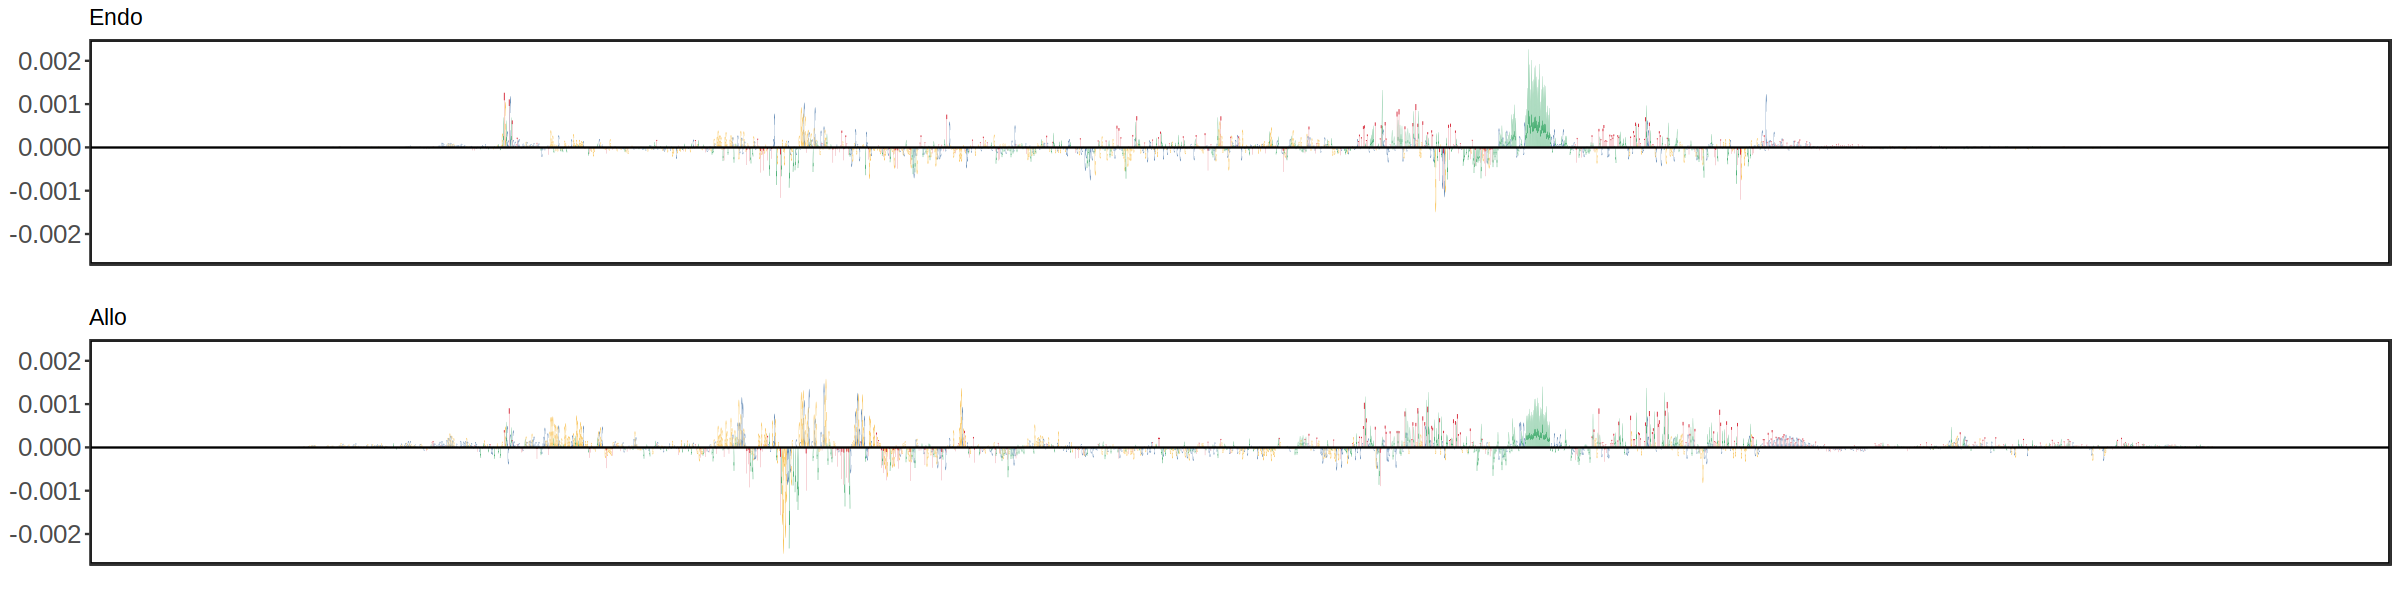

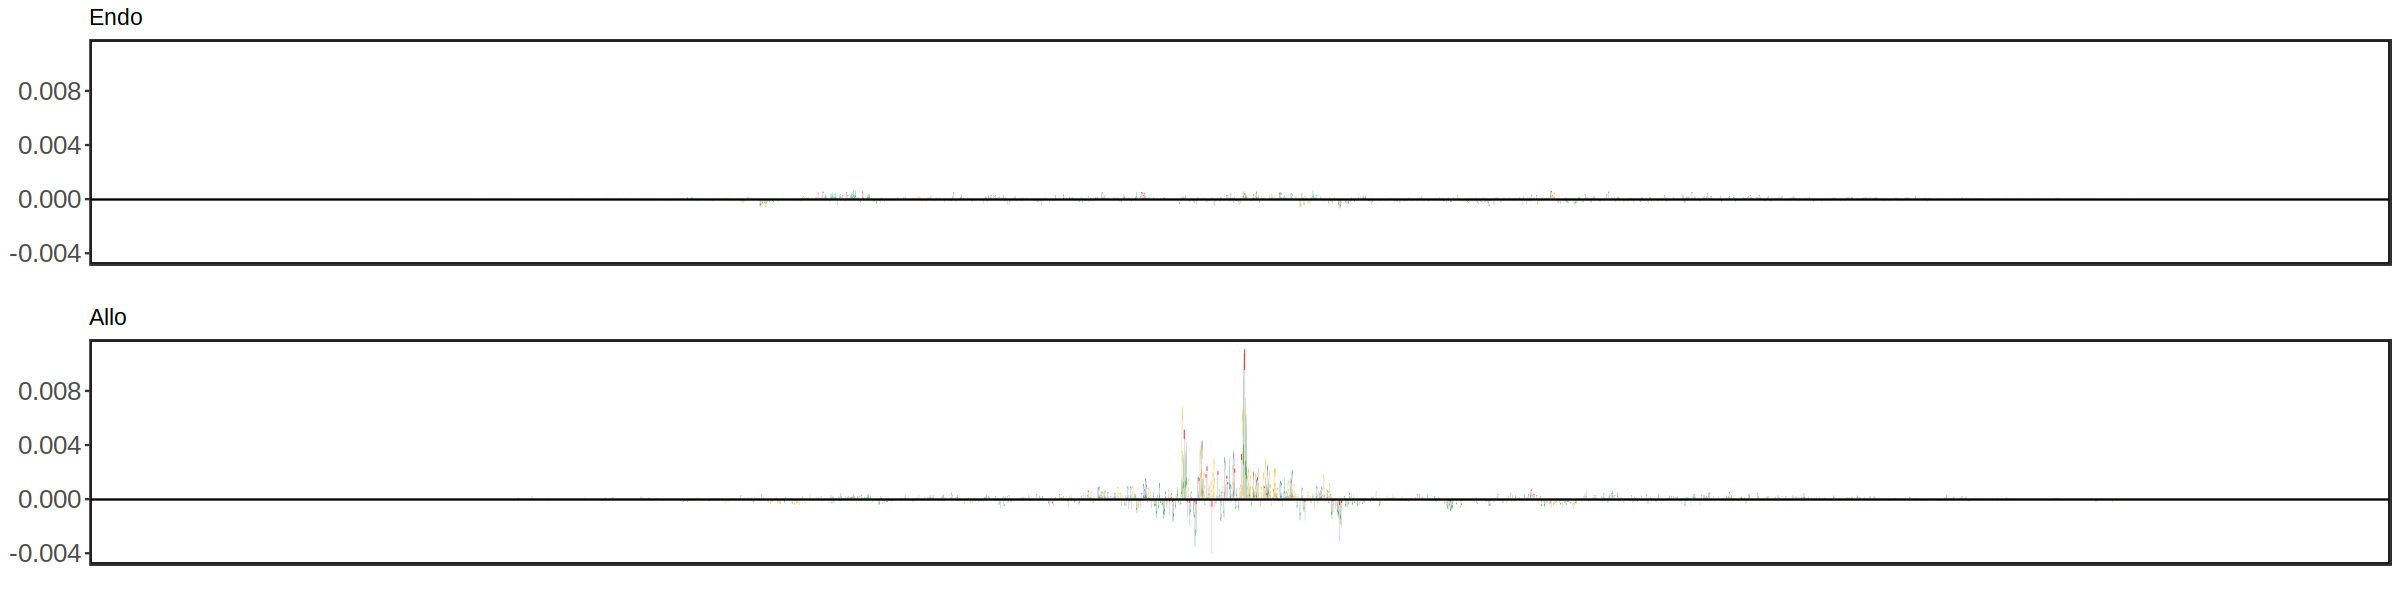

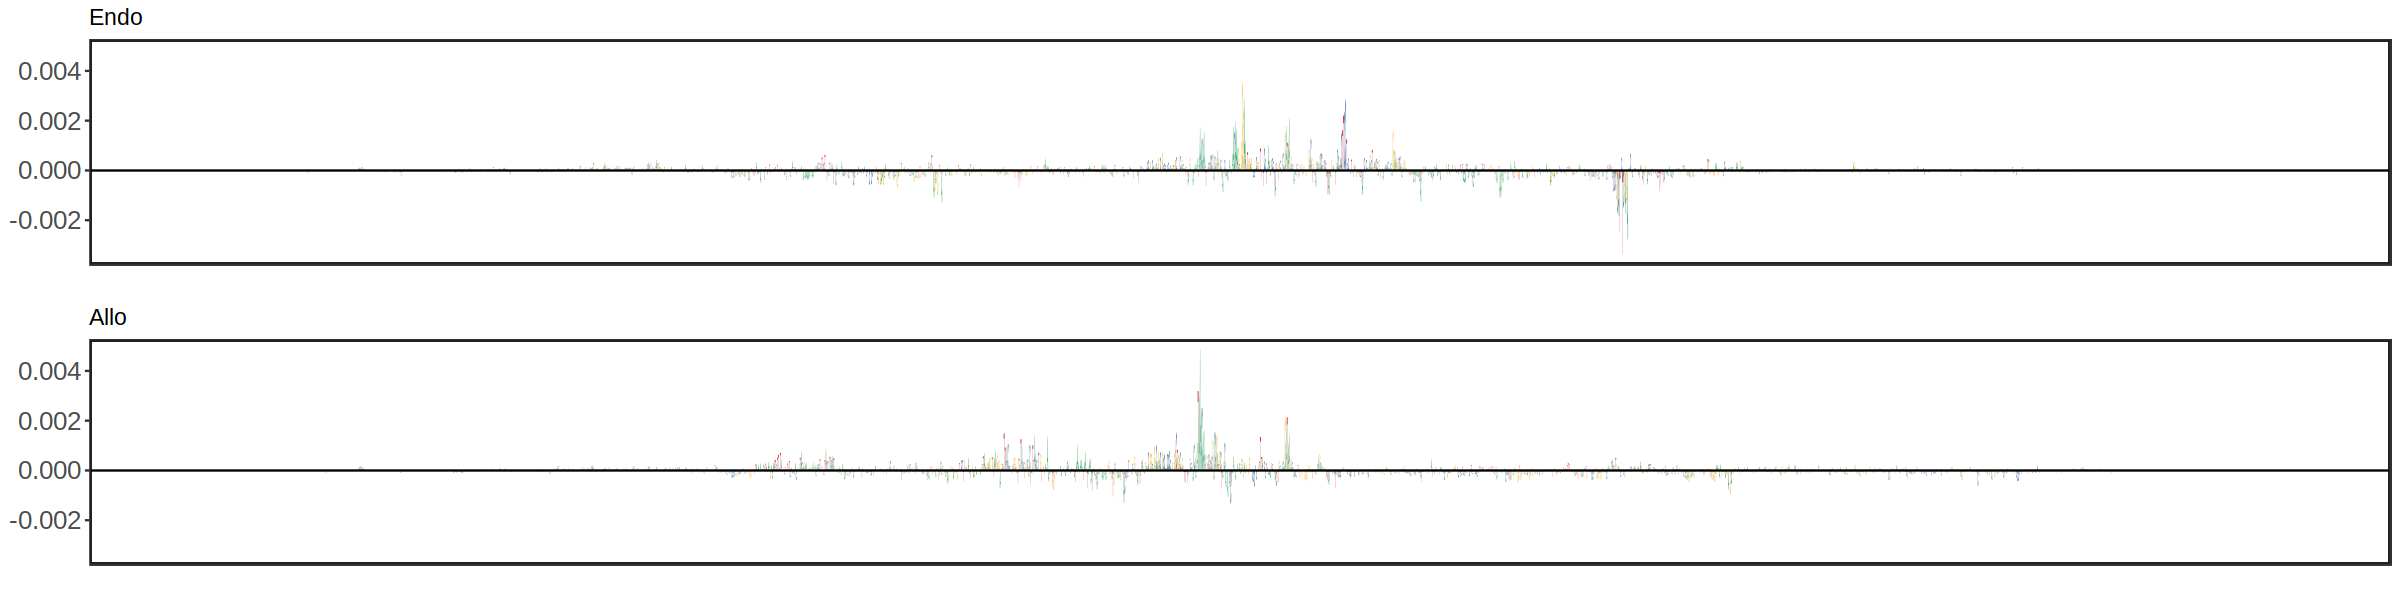

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


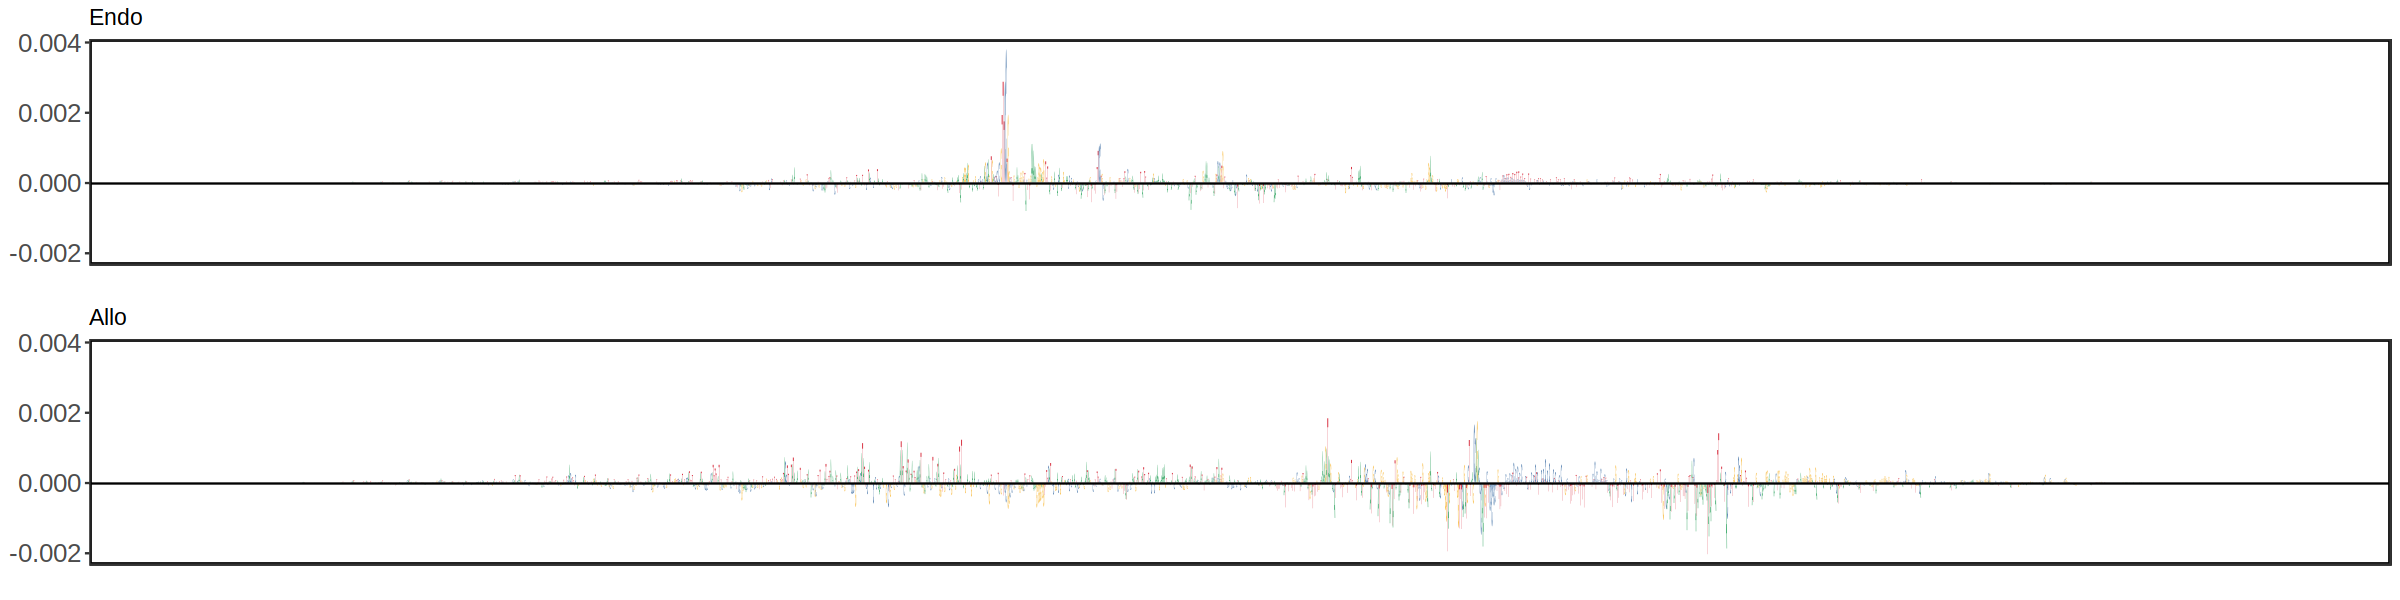

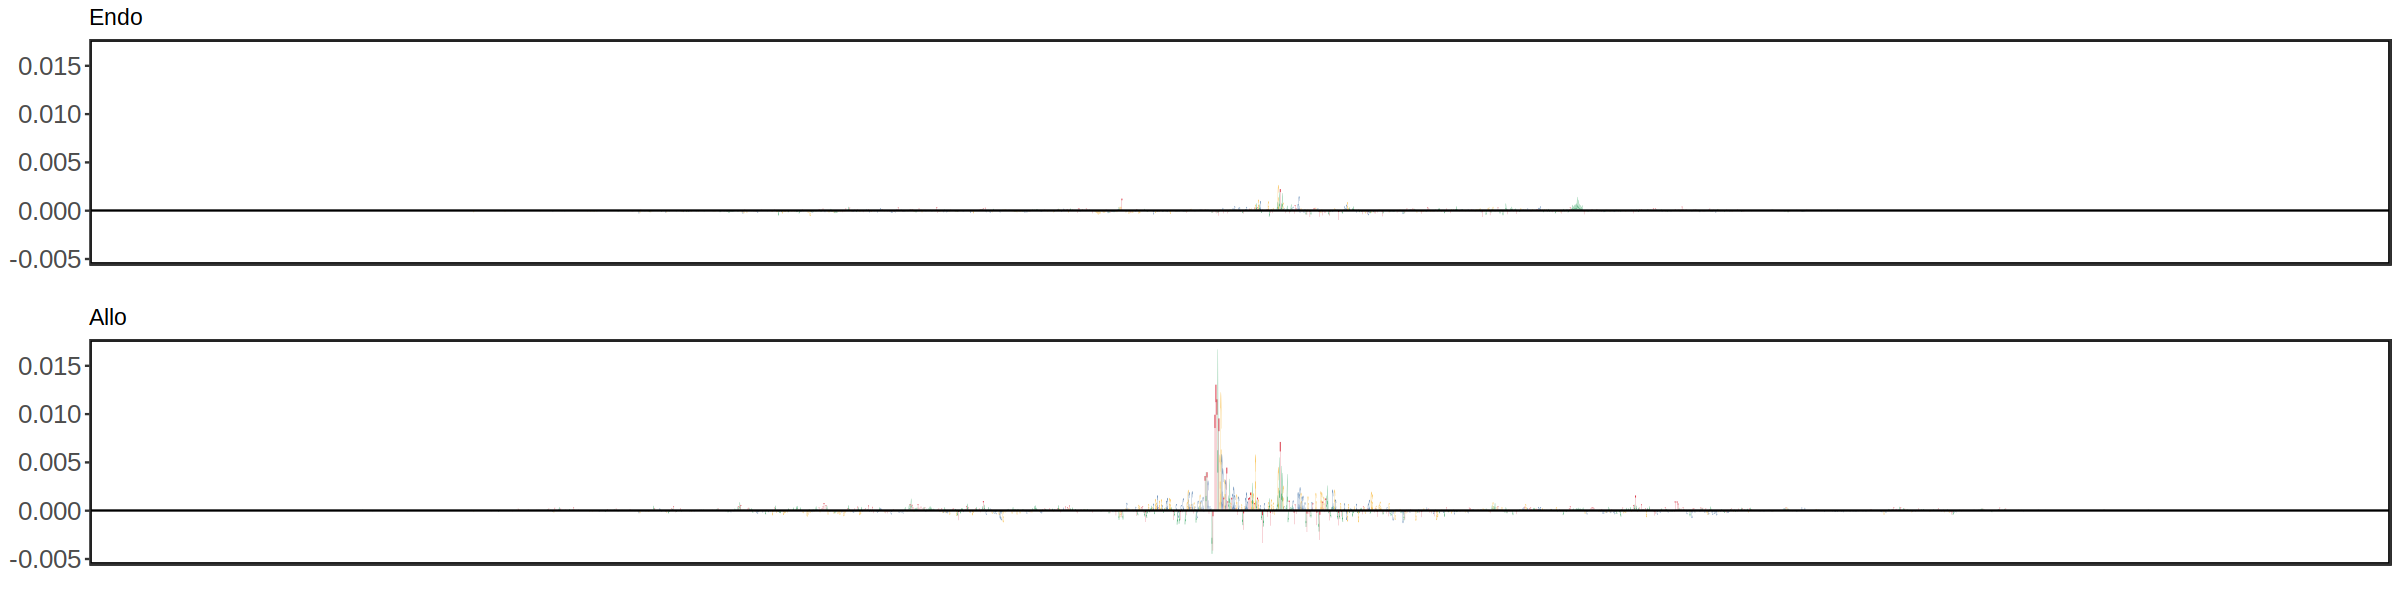

In [180]:
lapply(1:5, function(x){
    
    row = boom[x,]$endoIn
    endo = endo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_endo = as.matrix(t(data.table(A = endo[1:2114],
               C = endo[2115:4228],
               G =  endo[4229:6342],
               T =  endo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
             #   .[position > 200 & position < 1800] %>% 
                             .[, position := NULL]))

    row = boom[x,]$alloIn
    allo = allo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_allo = as.matrix(t(data.table(A = allo[1:2114],
               C = allo[2115:4228],
               G =  allo[4229:6342],
               T =  allo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
           #     .[position > 200 & position < 1800] %>% 
                             .[, position := NULL]))
        
    min = min(c(genome_endo, genome_allo))
    max = max(c(genome_endo, genome_allo))
    options(repr.plot.width = 20, repr.plot.height = 5)
    
    #genome = genome[position > 800 & position < 1200]
    p1 = ggseqlogo(genome_endo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) +
        ylim(min, max) + 
        ggtitle('Endo') + 
            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())
    
    p2 = ggseqlogo(genome_allo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) + 
                ylim(min, max) + 
            ggtitle('Allo') + 

            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())

    p = ggarrange(p1, p2, ncol = 1)
    return(p)
})

In [181]:
# Identify endo enhancers
boom = mclapply(regions$alloI, function(x){
    test = allo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    tmp1 = regions[alloI == x,]
    
    tmp = data.table(max = mean(test),
                     endoIn = tmp1$endoI ,
                     alloIn = tmp1$alloI )
                     
   return(tmp)
}, mc.cores = 24) %>% rbindlist() %>%
    .[order(-max)]

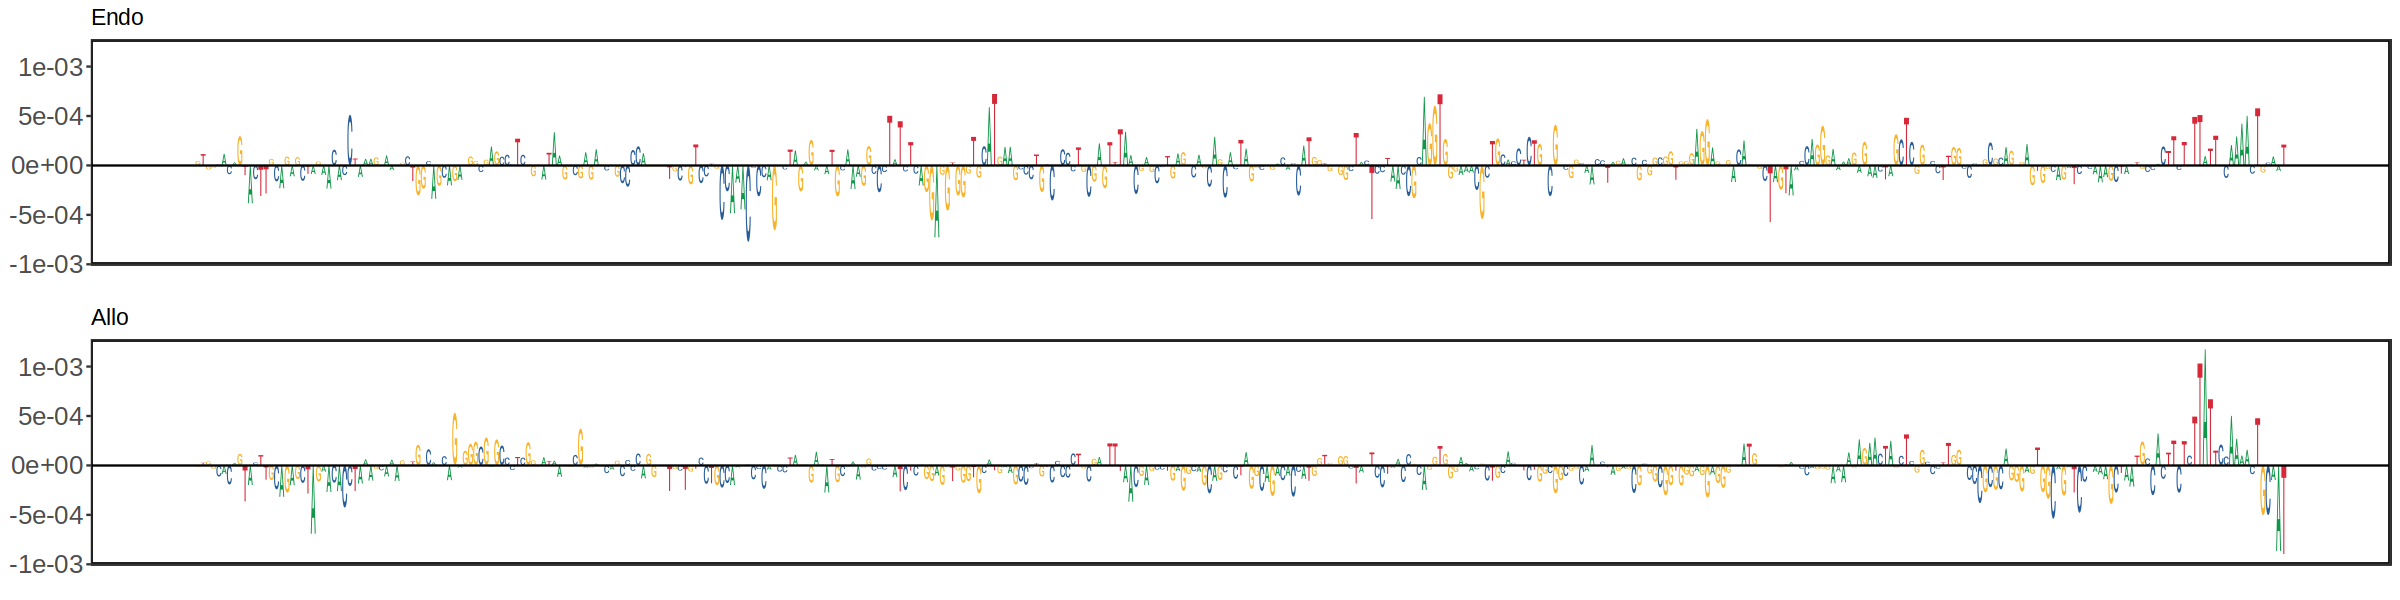

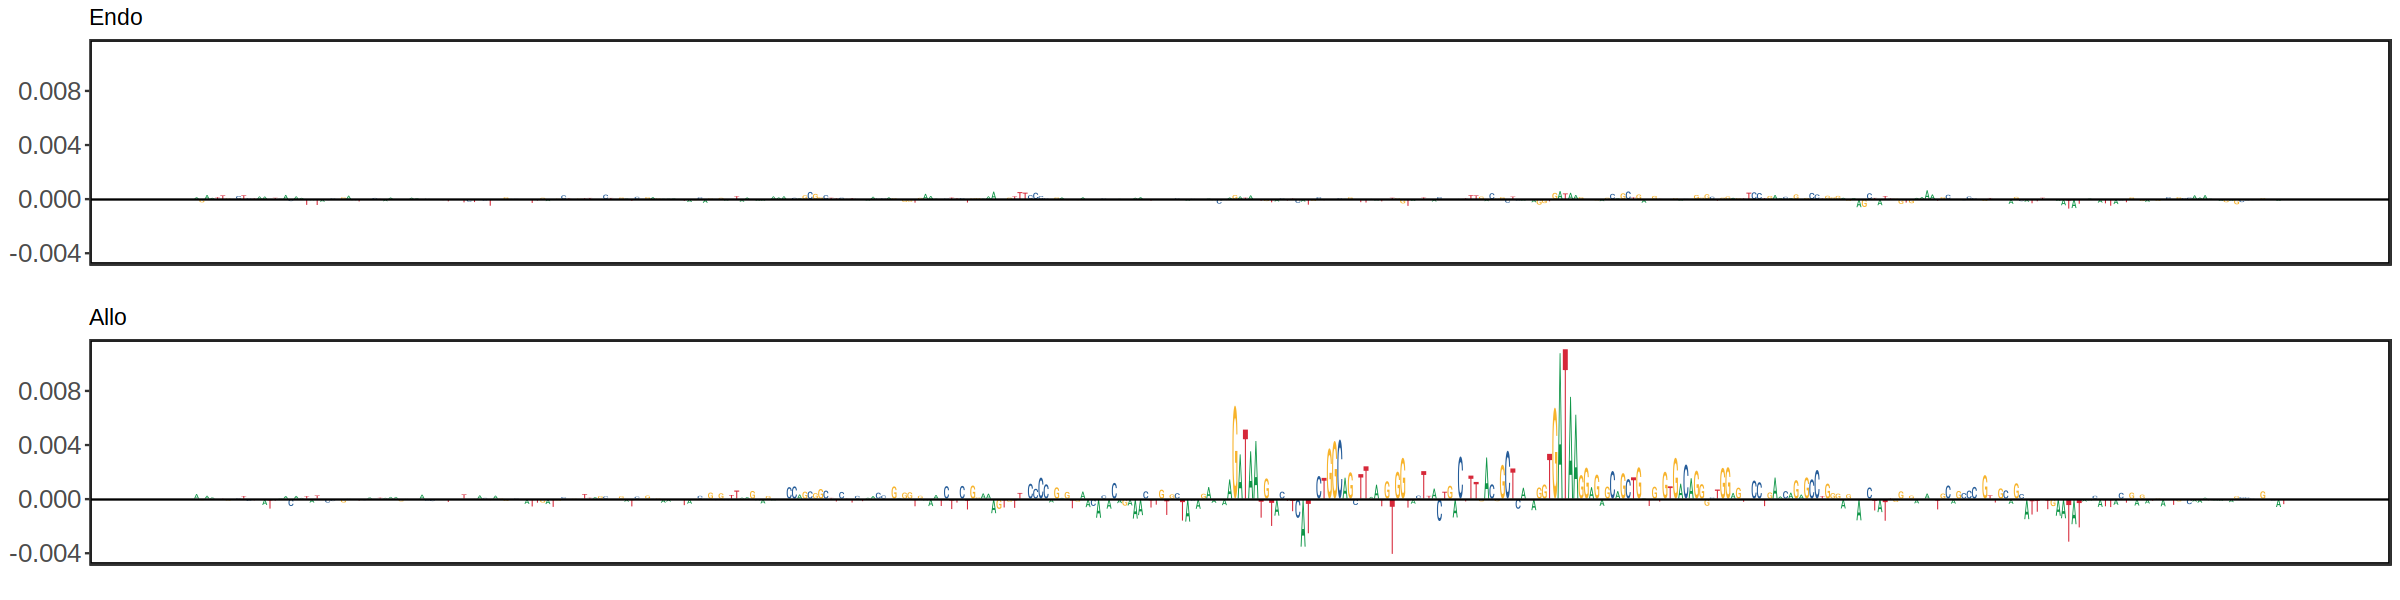

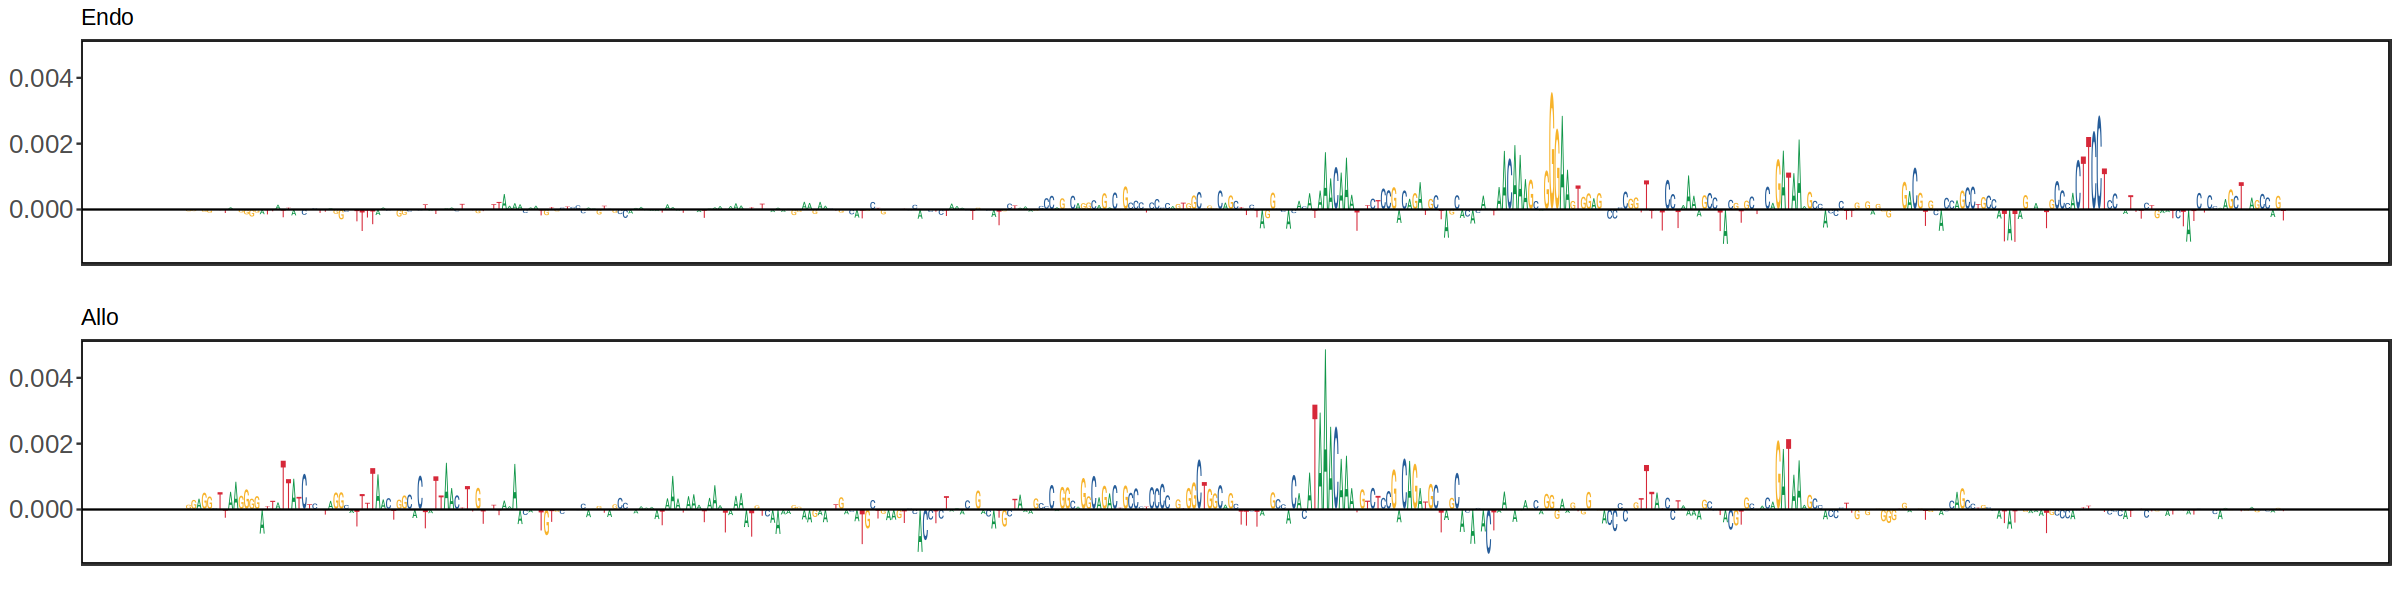

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


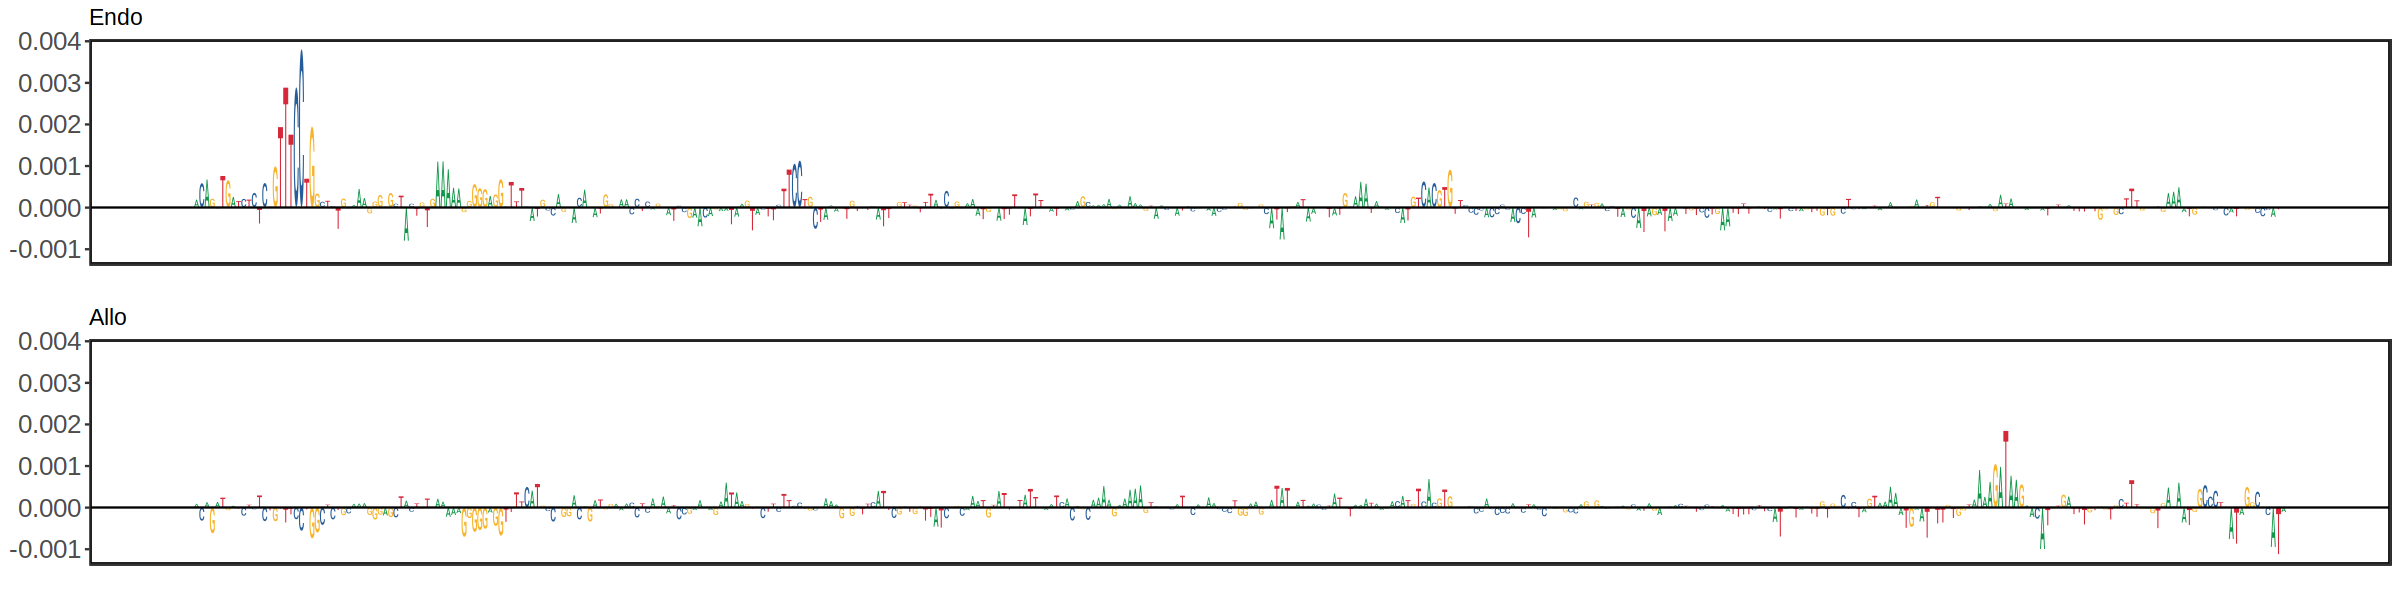

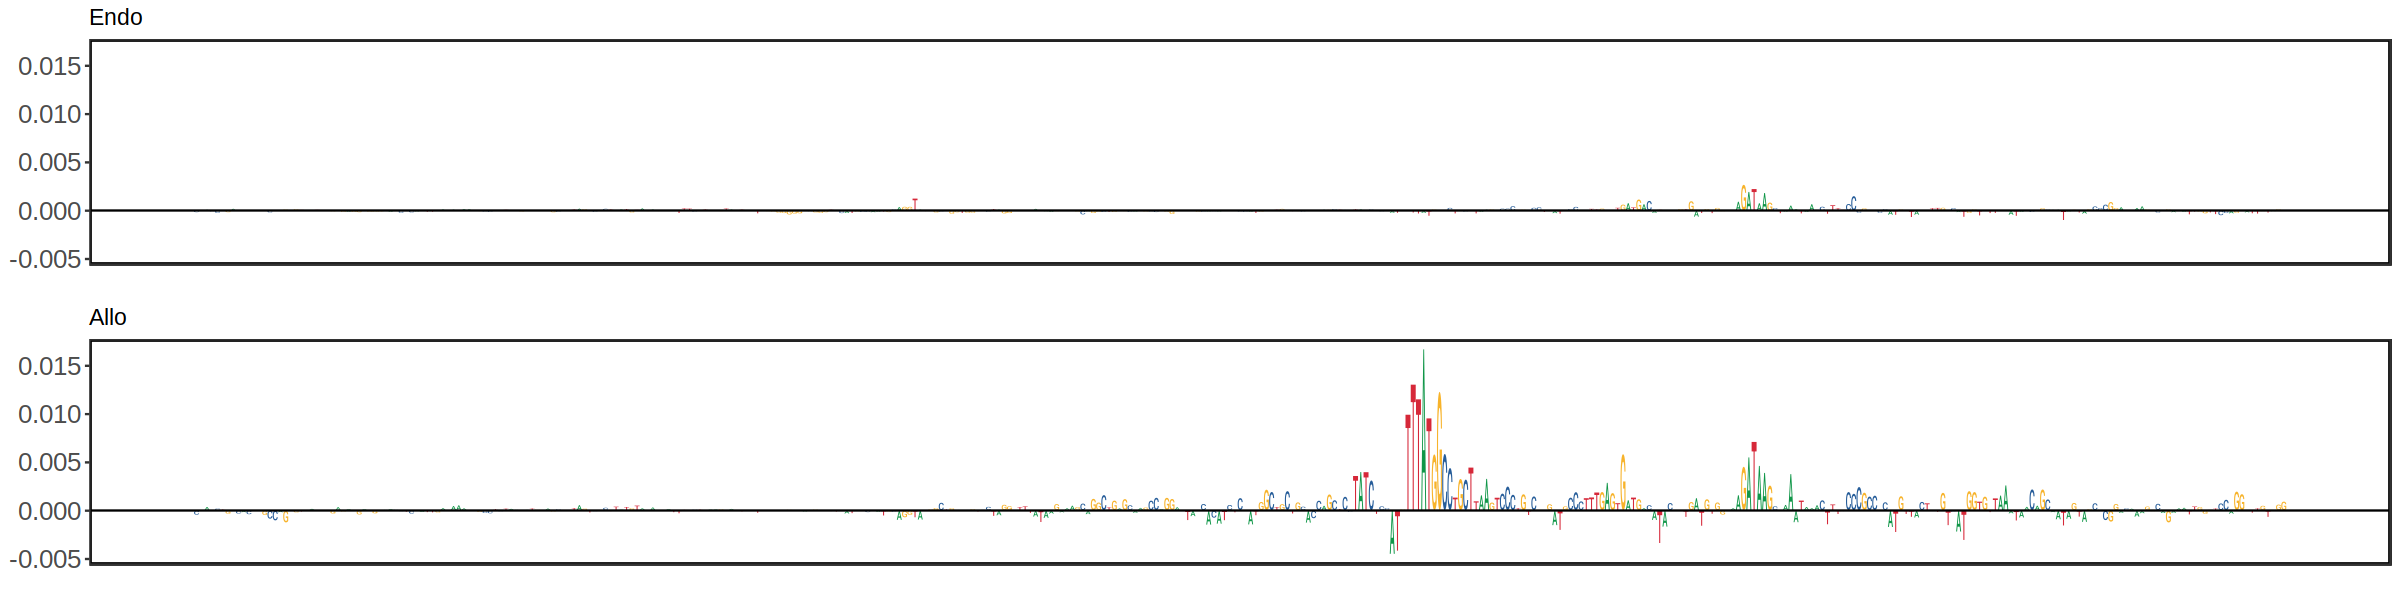

In [182]:
lapply(1:5, function(x){
    
    row = boom[x,]$endoIn
    endo = endo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_endo = as.matrix(t(data.table(A = endo[1:2114],
               C = endo[2115:4228],
               G =  endo[4229:6342],
               T =  endo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
                .[position > 800 & position < 1200] %>% 
                             .[, position := NULL]))

    row = boom[x,]$alloIn
    allo = allo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_allo = as.matrix(t(data.table(A = allo[1:2114],
               C = allo[2115:4228],
               G =  allo[4229:6342],
               T =  allo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
                .[position > 800 & position < 1200] %>% 
                             .[, position := NULL]))
        
    min = min(c(genome_endo, genome_allo))
    max = max(c(genome_endo, genome_allo))
    options(repr.plot.width = 20, repr.plot.height = 5)
    
    #genome = genome[position > 800 & position < 1200]
    p1 = ggseqlogo(genome_endo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) +
        ylim(min, max) + 
        ggtitle('Endo') + 
            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())
    
    p2 = ggseqlogo(genome_allo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) + 
                ylim(min, max) + 
            ggtitle('Allo') + 

            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())

    p = ggarrange(p1, p2, ncol = 1)
    return(p)
})

## Only looking at endo & all independently

In [186]:
# Identify endo enhancers
boom = mclapply(1:3000, function(x){
    row = x
    test = endo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    
    tmp = data.table(max = mean(test),
                     I = x)
                     
   return(tmp)
}, mc.cores = 24) %>% rbindlist() %>%
    .[order(-max)]

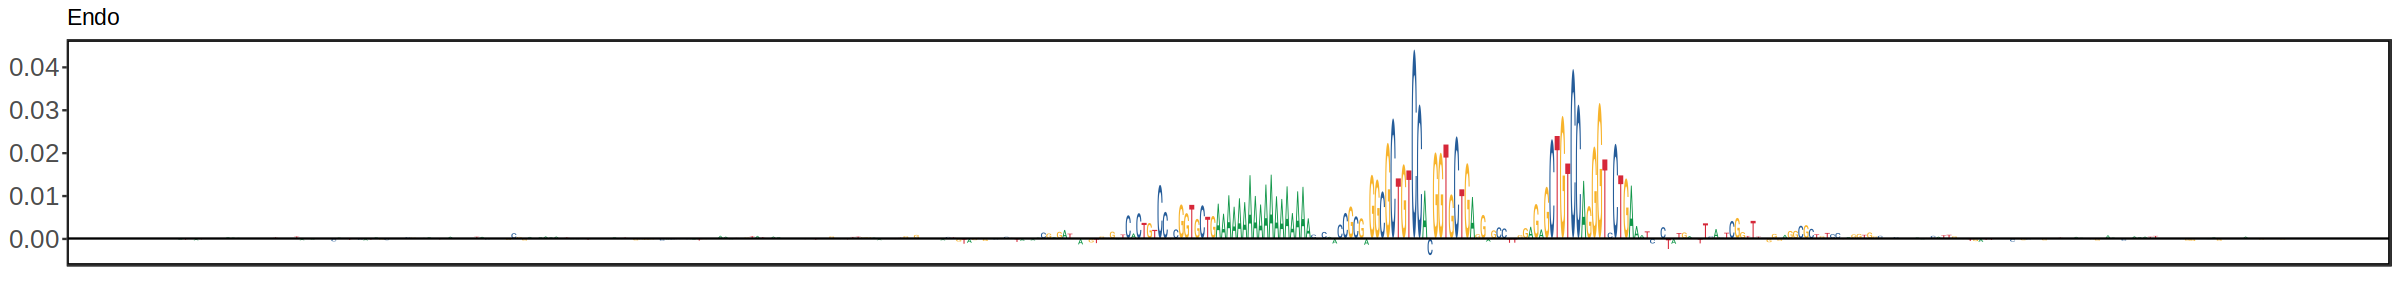

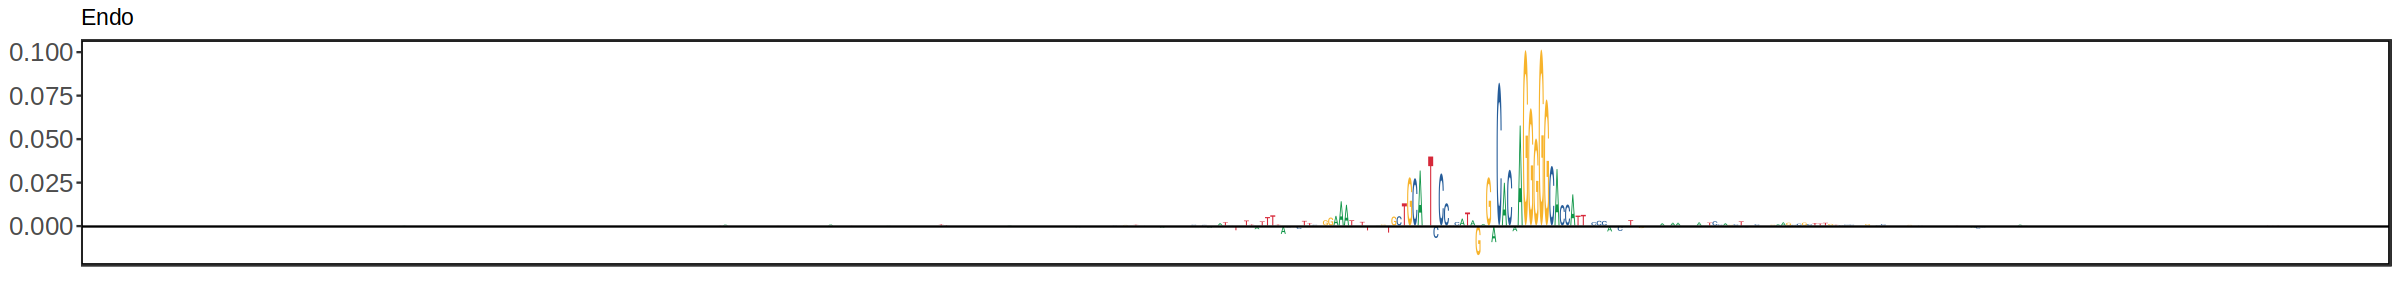

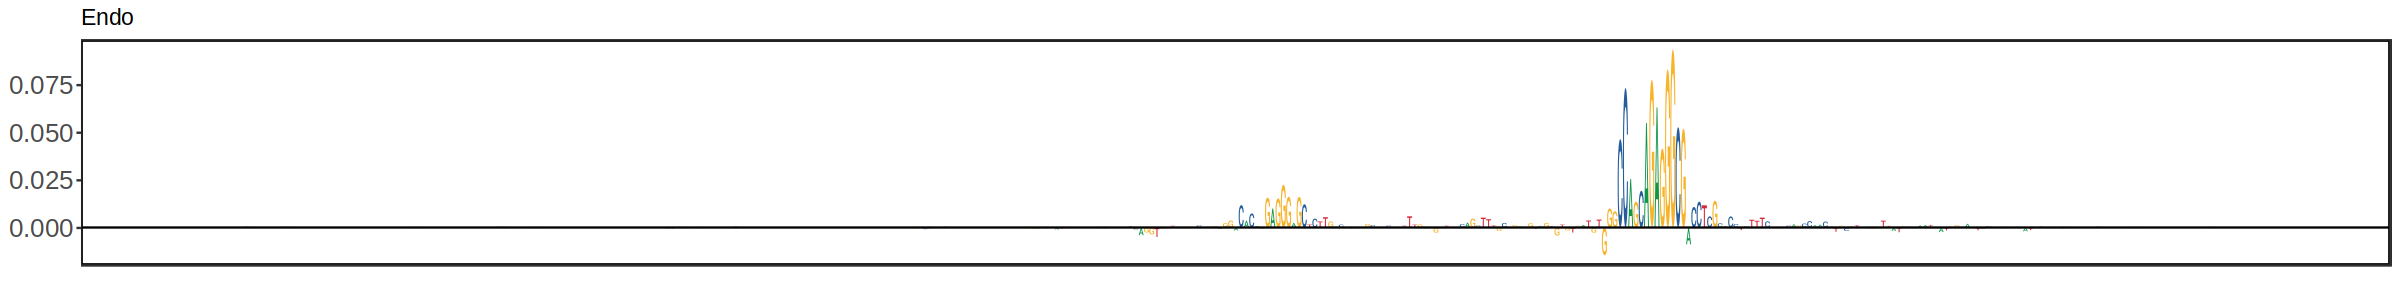

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


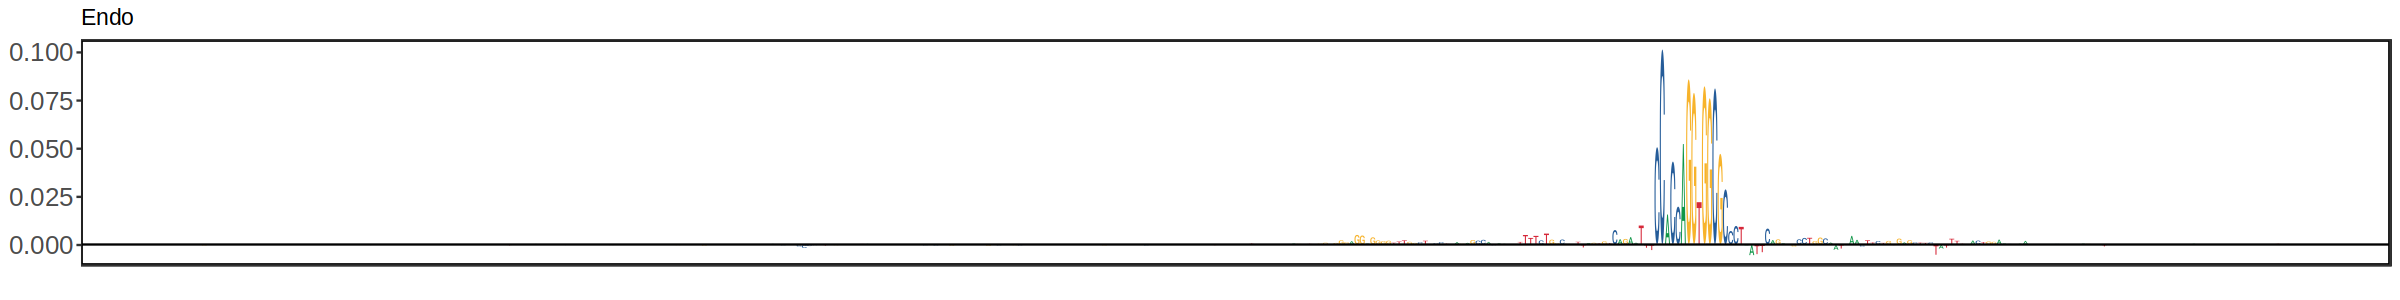

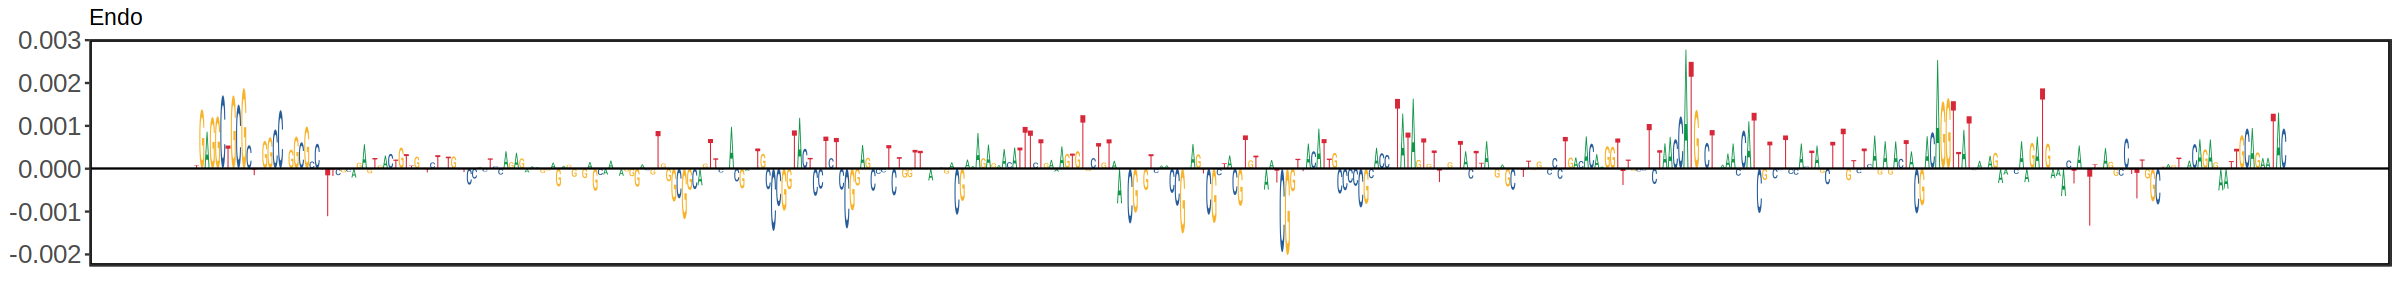

In [192]:
lapply(1:5, function(x){
    
    row = boom[x,]$I
    endo = endo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_endo = as.matrix(t(data.table(A = endo[1:2114],
               C = endo[2115:4228],
               G =  endo[4229:6342],
               T =  endo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
                .[position > 800 & position < 1200] %>% 
                             .[, position := NULL]))

    options(repr.plot.width = 20, repr.plot.height = 2.5)
    p1 = ggseqlogo(genome_endo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) +
        ggtitle('Endo') + 
            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())
    return(p1)
})

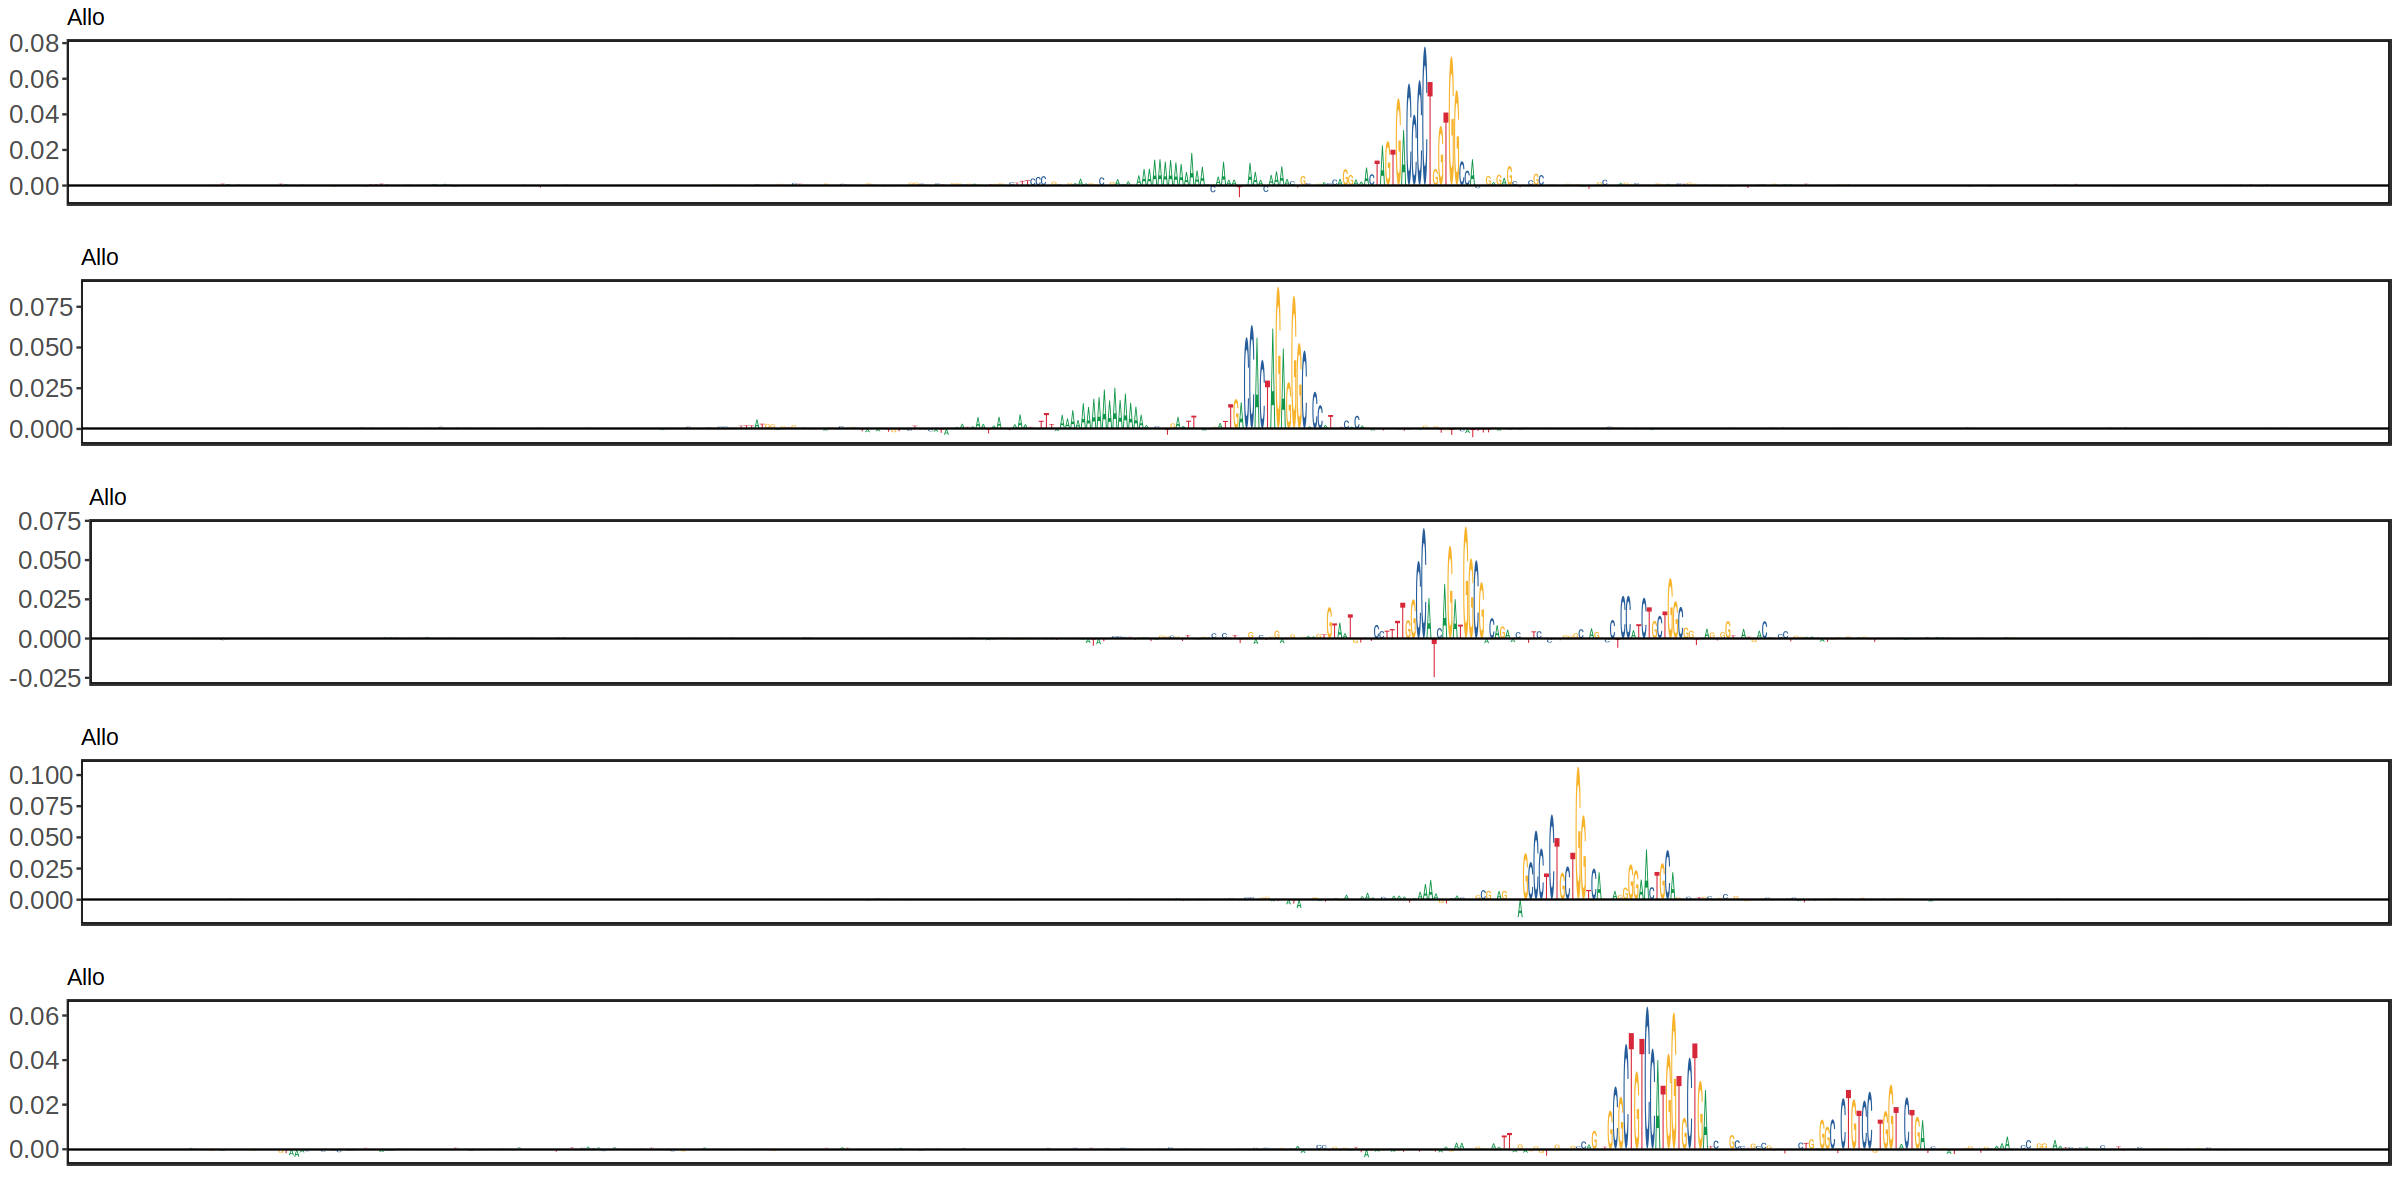

In [196]:
# Identify endo enhancers
boom = mclapply(1:3000, function(x){
    row = x
    test = allo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    
    tmp = data.table(max = mean(test),
                     I = x)
                     
   return(tmp)
}, mc.cores = 24) %>% rbindlist() %>%
    .[order(-max)]

p = lapply(1:5, function(x){
    
    row = boom[x,]$I
    allo = allo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_allo = as.matrix(t(data.table(A = allo[1:2114],
               C = allo[2115:4228],
               G =  allo[4229:6342],
               T =  allo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
                .[position > 800 & position < 1200] %>% 
                             .[, position := NULL]))

    p1 = ggseqlogo(genome_allo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) +
        ggtitle('Allo') + 
            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())
    return(p1)
})
options(repr.plot.width = 20, repr.plot.height = 10)
ggarrange(plotlist = p, ncol = 1)

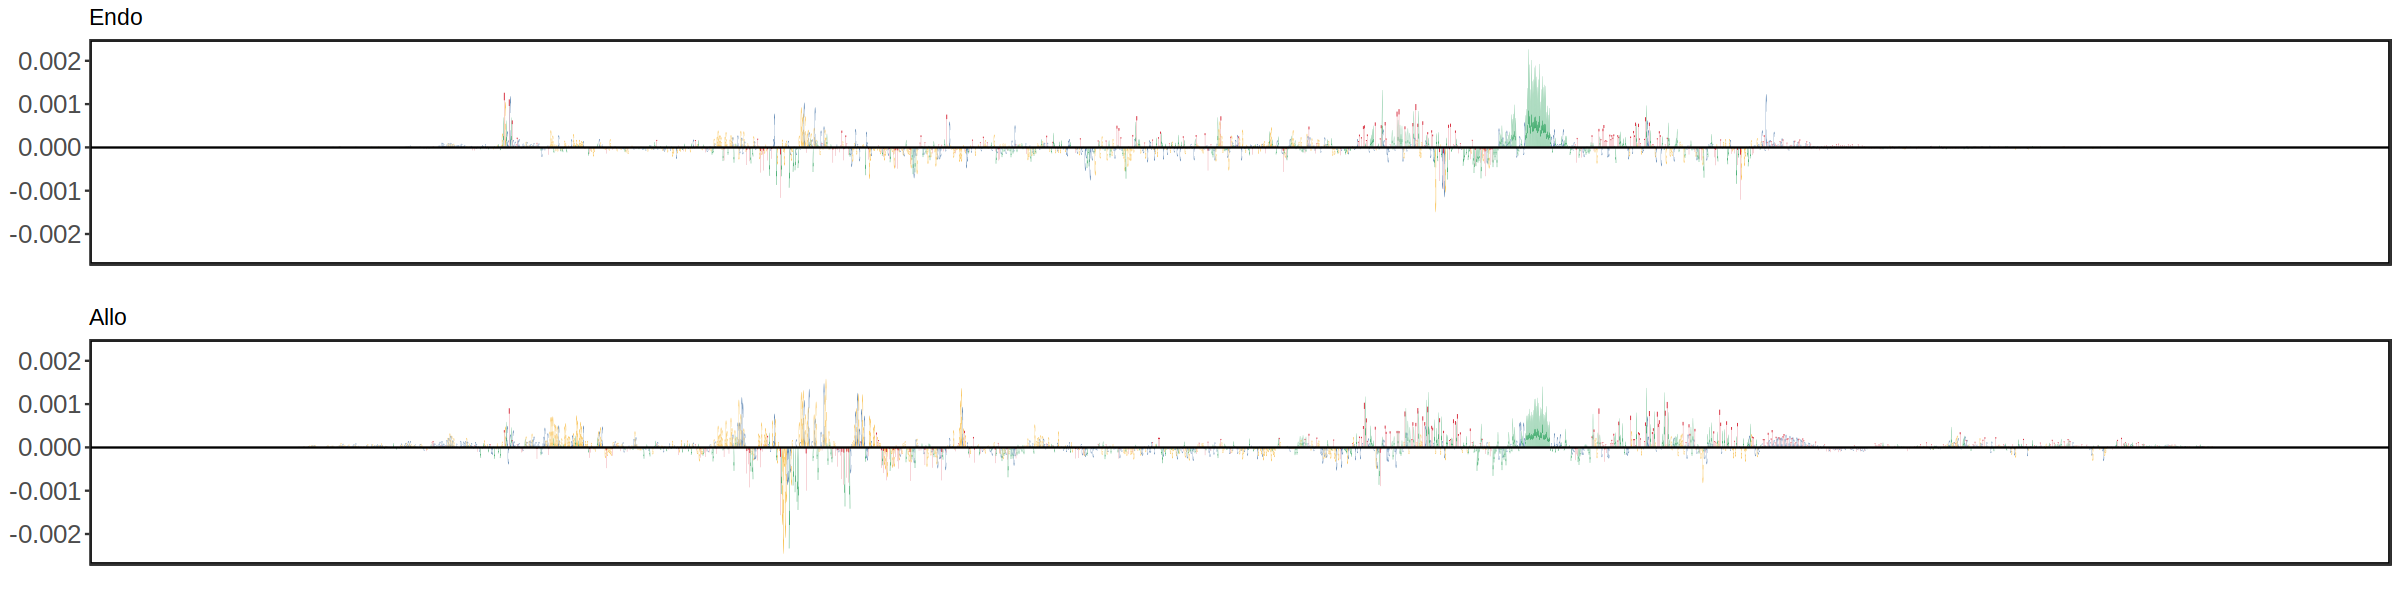

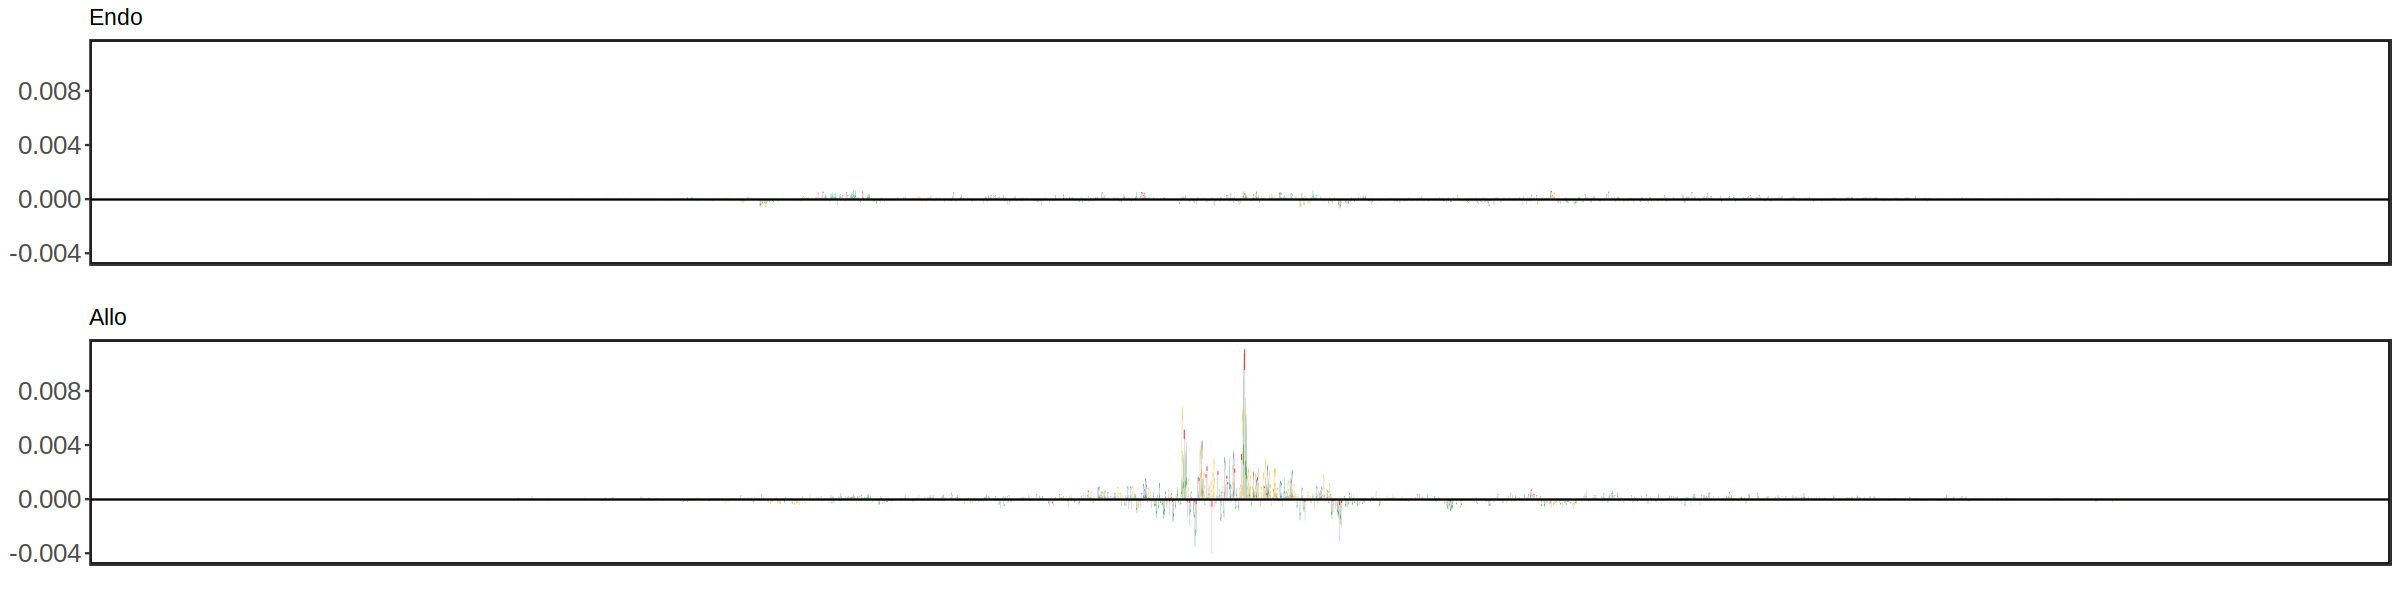

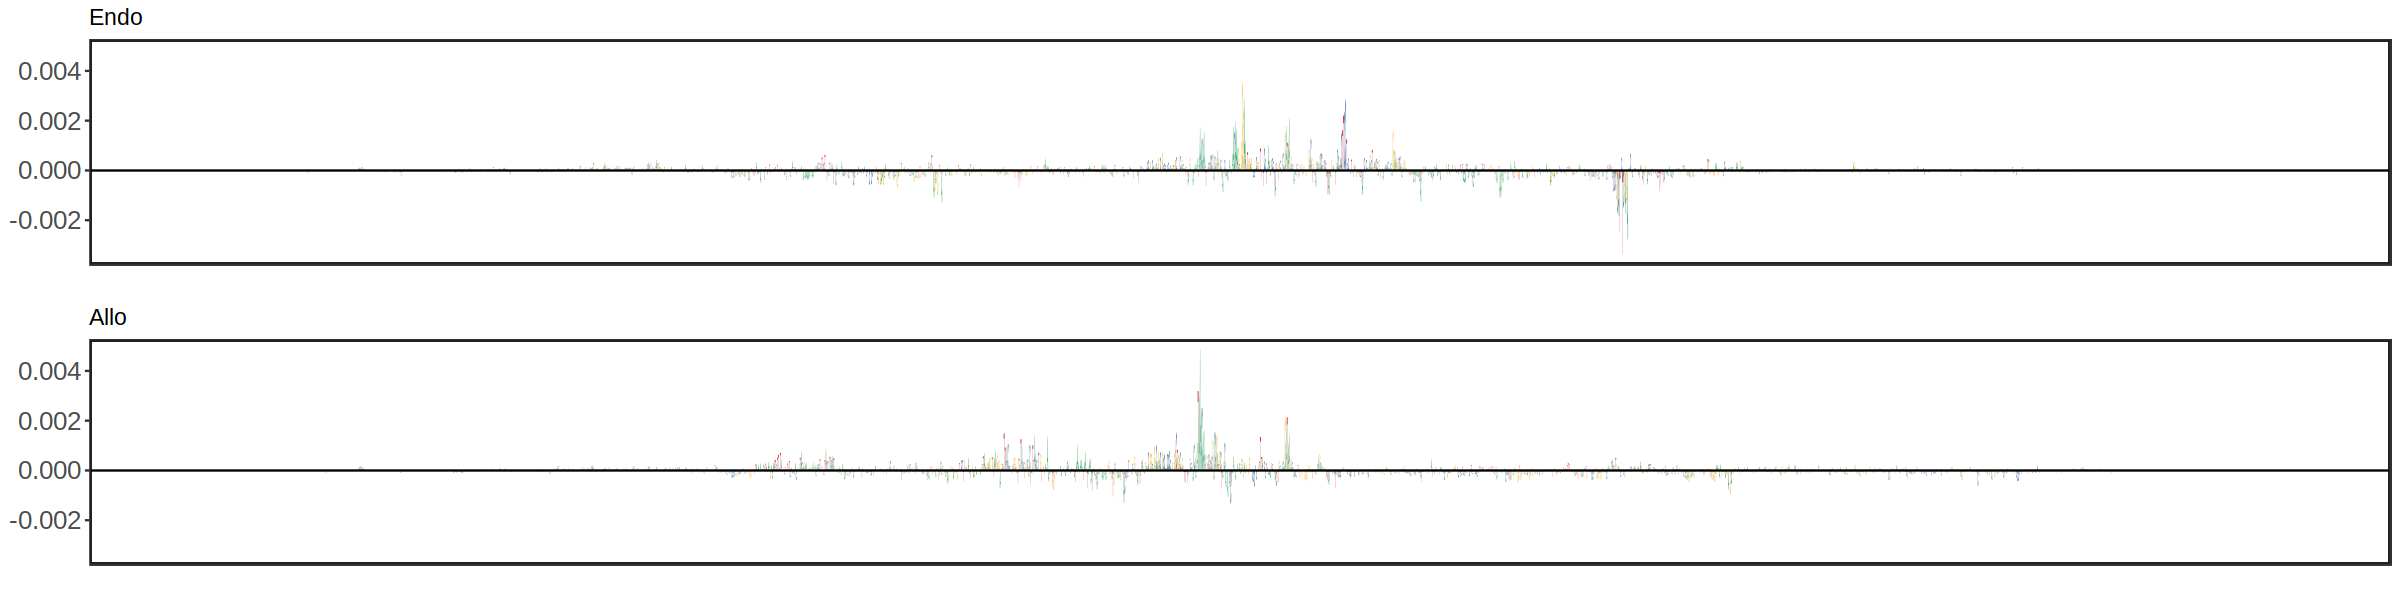

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


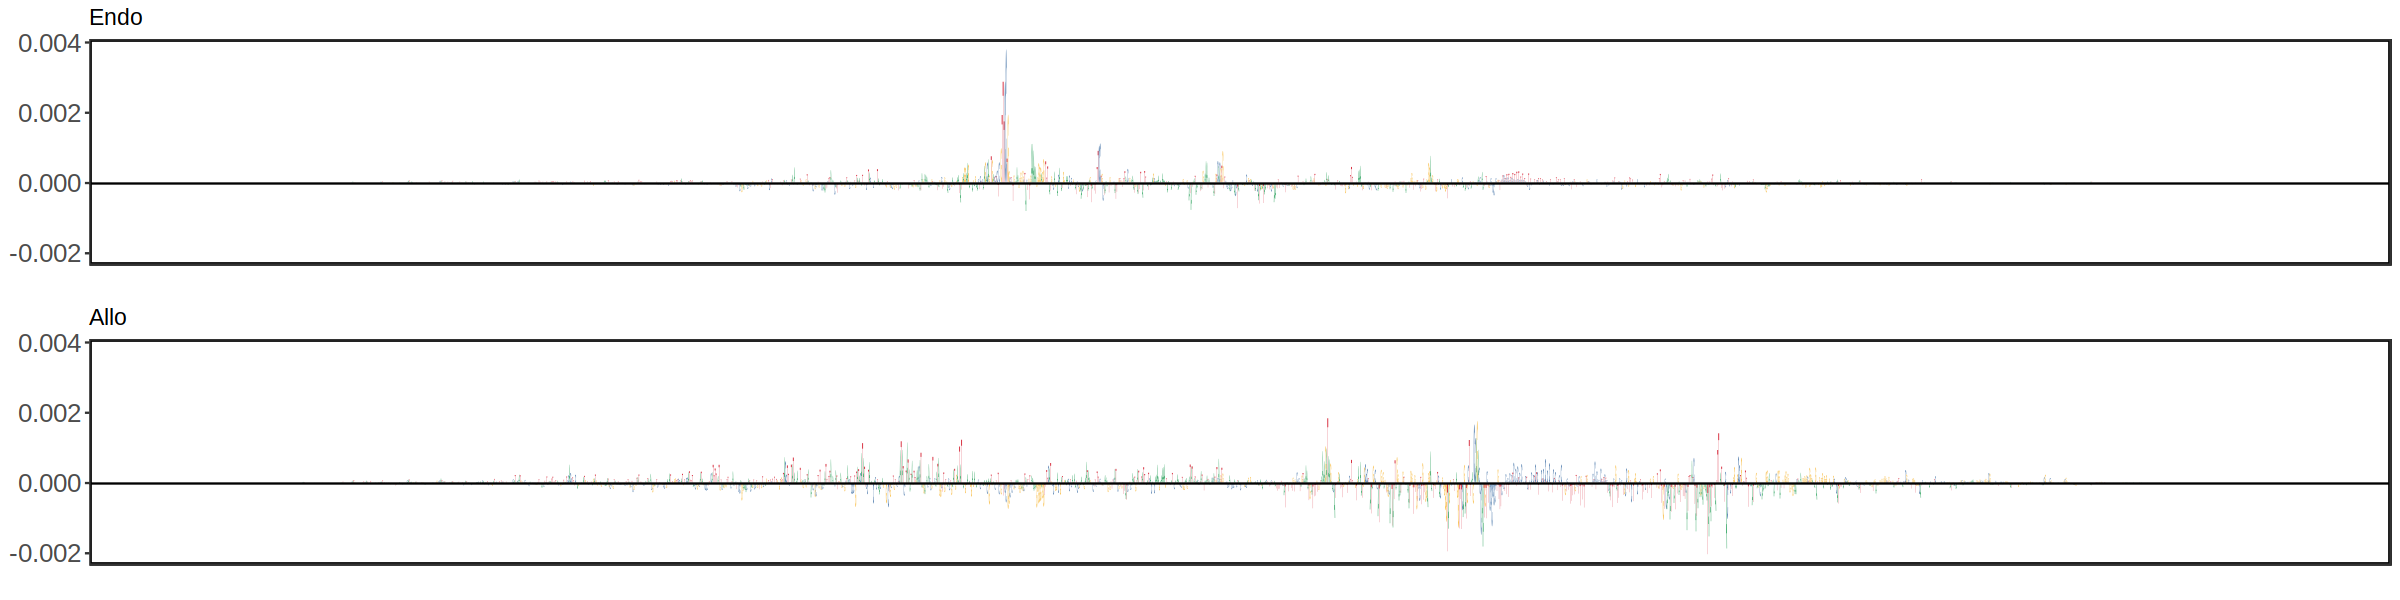

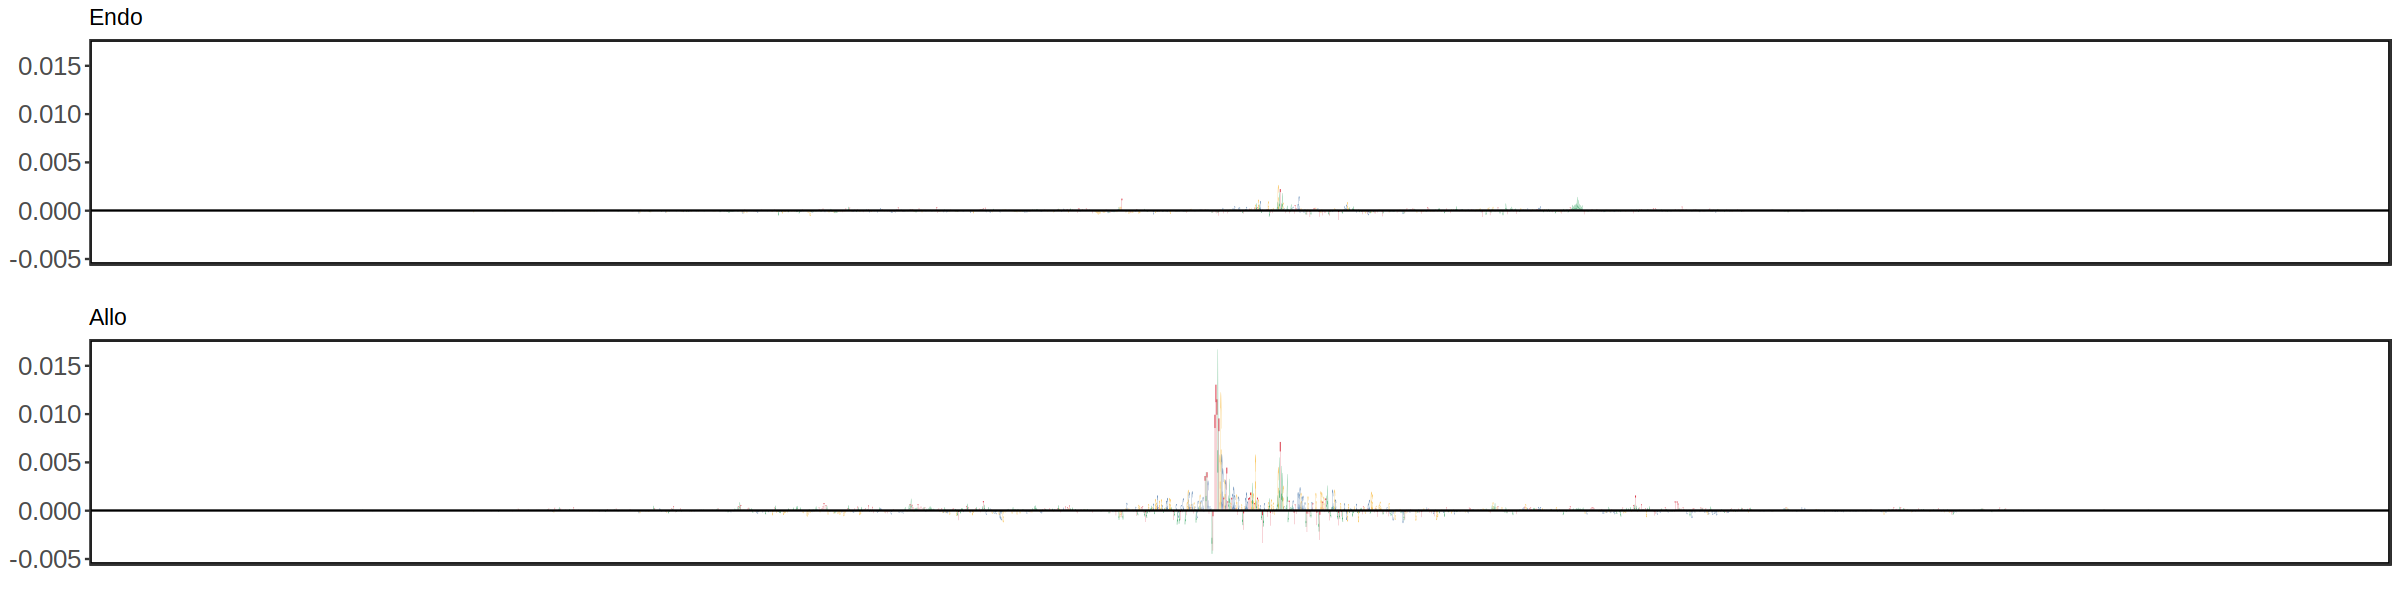

In [180]:
lapply(1:5, function(x){
    
    row = boom[x,]$endoIn
    endo = endo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_endo = as.matrix(t(data.table(A = endo[1:2114],
               C = endo[2115:4228],
               G =  endo[4229:6342],
               T =  endo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
             #   .[position > 200 & position < 1800] %>% 
                             .[, position := NULL]))

    row = boom[x,]$alloIn
    allo = allo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_allo = as.matrix(t(data.table(A = allo[1:2114],
               C = allo[2115:4228],
               G =  allo[4229:6342],
               T =  allo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
           #     .[position > 200 & position < 1800] %>% 
                             .[, position := NULL]))
        
    min = min(c(genome_endo, genome_allo))
    max = max(c(genome_endo, genome_allo))
    options(repr.plot.width = 20, repr.plot.height = 5)
    
    #genome = genome[position > 800 & position < 1200]
    p1 = ggseqlogo(genome_endo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) +
        ylim(min, max) + 
        ggtitle('Endo') + 
            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())
    
    p2 = ggseqlogo(genome_allo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) + 
                ylim(min, max) + 
            ggtitle('Allo') + 

            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())

    p = ggarrange(p1, p2, ncol = 1)
    return(p)
})

# Test predictions over known regions

For the 2 enhancers that we're testing it already seems like the count does a much better job at predicting why the Tbx4 enhancer is active.... Maybe ChromBPNet is just overkill and the regular count prediction as implemenented in CREsted should be enough?

In [6]:
# In command line:
# chrombpnet contribs_bw  -m ../../../results/atac/chrombpnet/Endothelium/models/chrombpnet_nobias.h5 \
#         -r test_prediction.bed \
#         -g /rds/project/rds-SDzz0CATGms/references/10x/refdata-cellranger-arc-mm10-2020-A-2.0.0/fasta/genome.fa \
#         -c ../../../results/atac/chrombpnet/mm10.chrom.sizes \
#         -op endo_test_prediction

## Profile prediction

In [18]:
celltype = 'Endothelium'
endo_h5 <- h5read('endo_test_prediction.profile_scores.h5', "/projected_shap/seq")
celltype = 'Allantois'
allo_h5 <- h5read('allo_test_prediction.profile_scores.h5', "/projected_shap/seq")

In [19]:
length(endo_h5)
length(allo_h5)

[1] 25368

[1] 25368

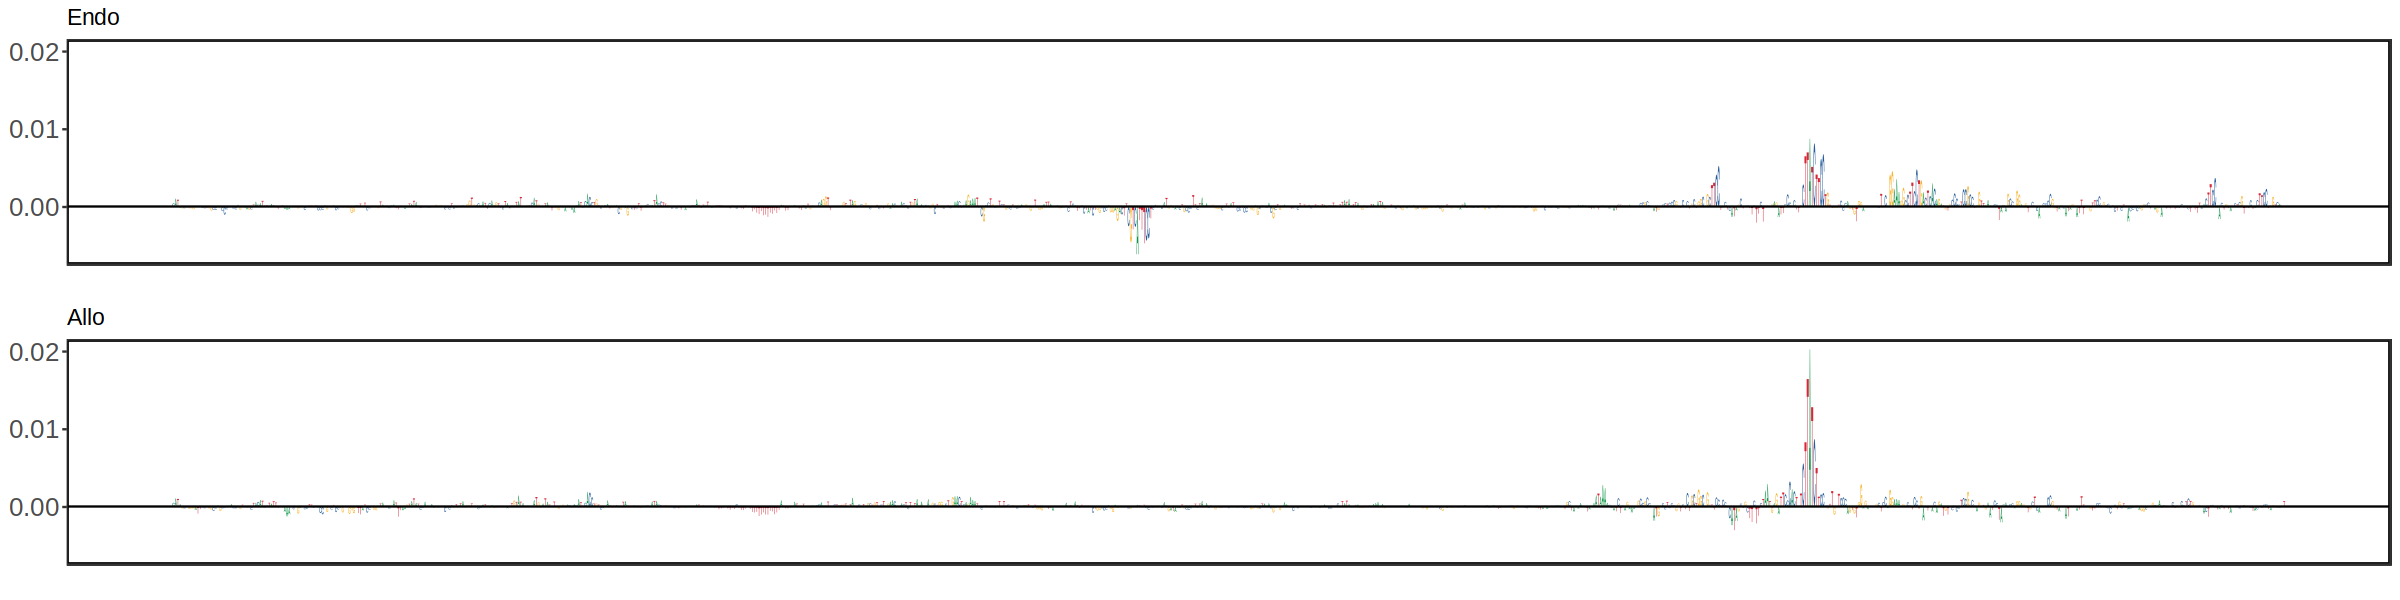

[[1]]

[[2]]

[[3]]


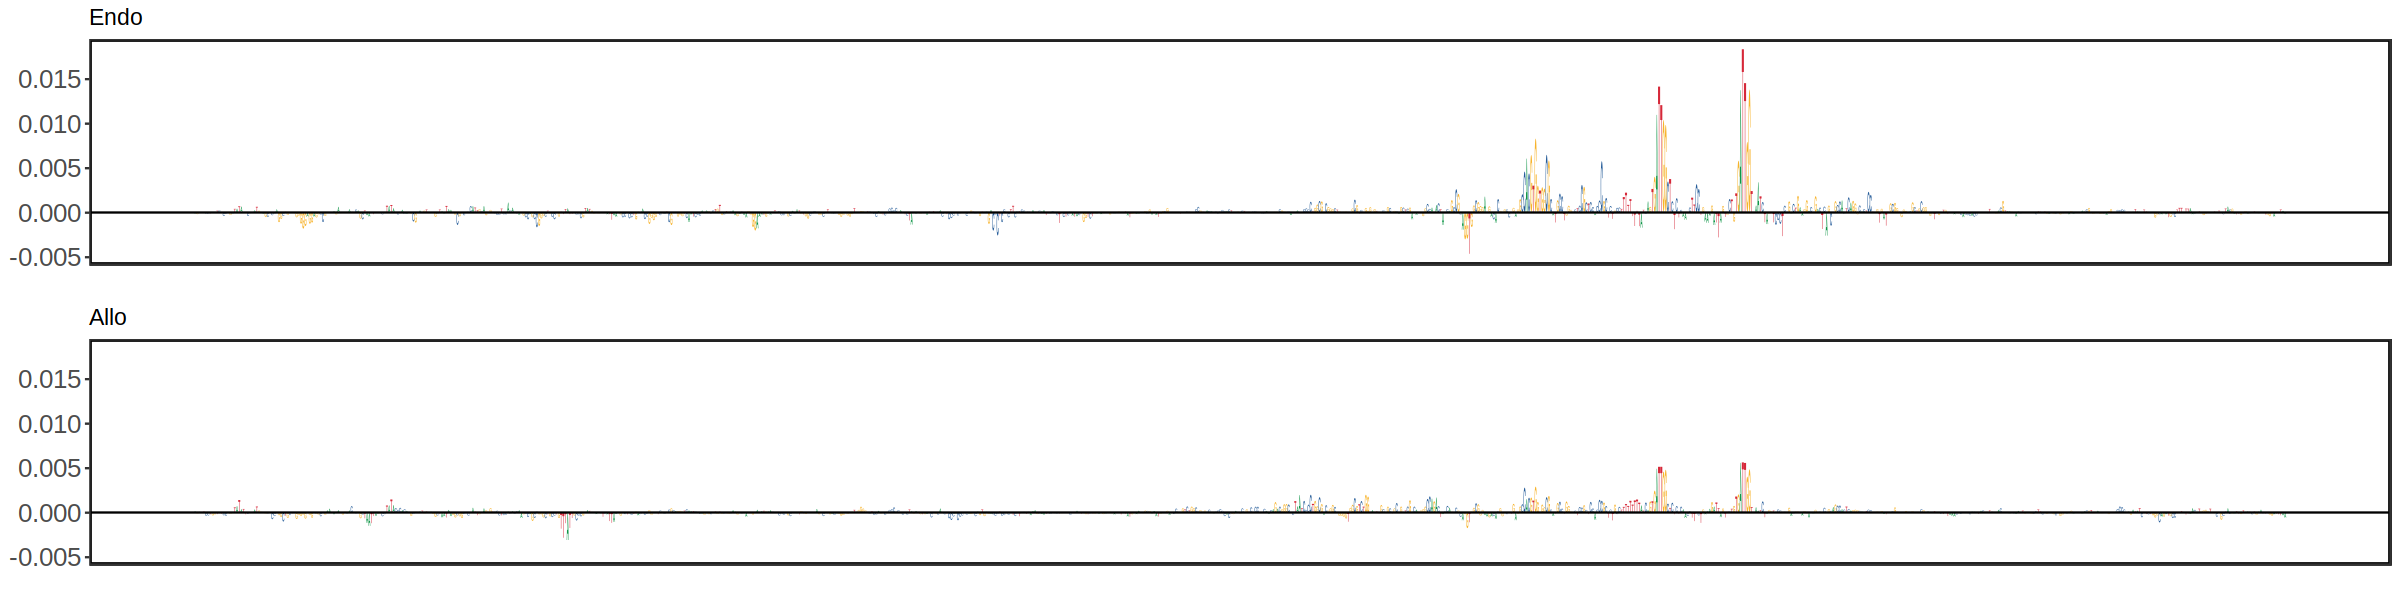

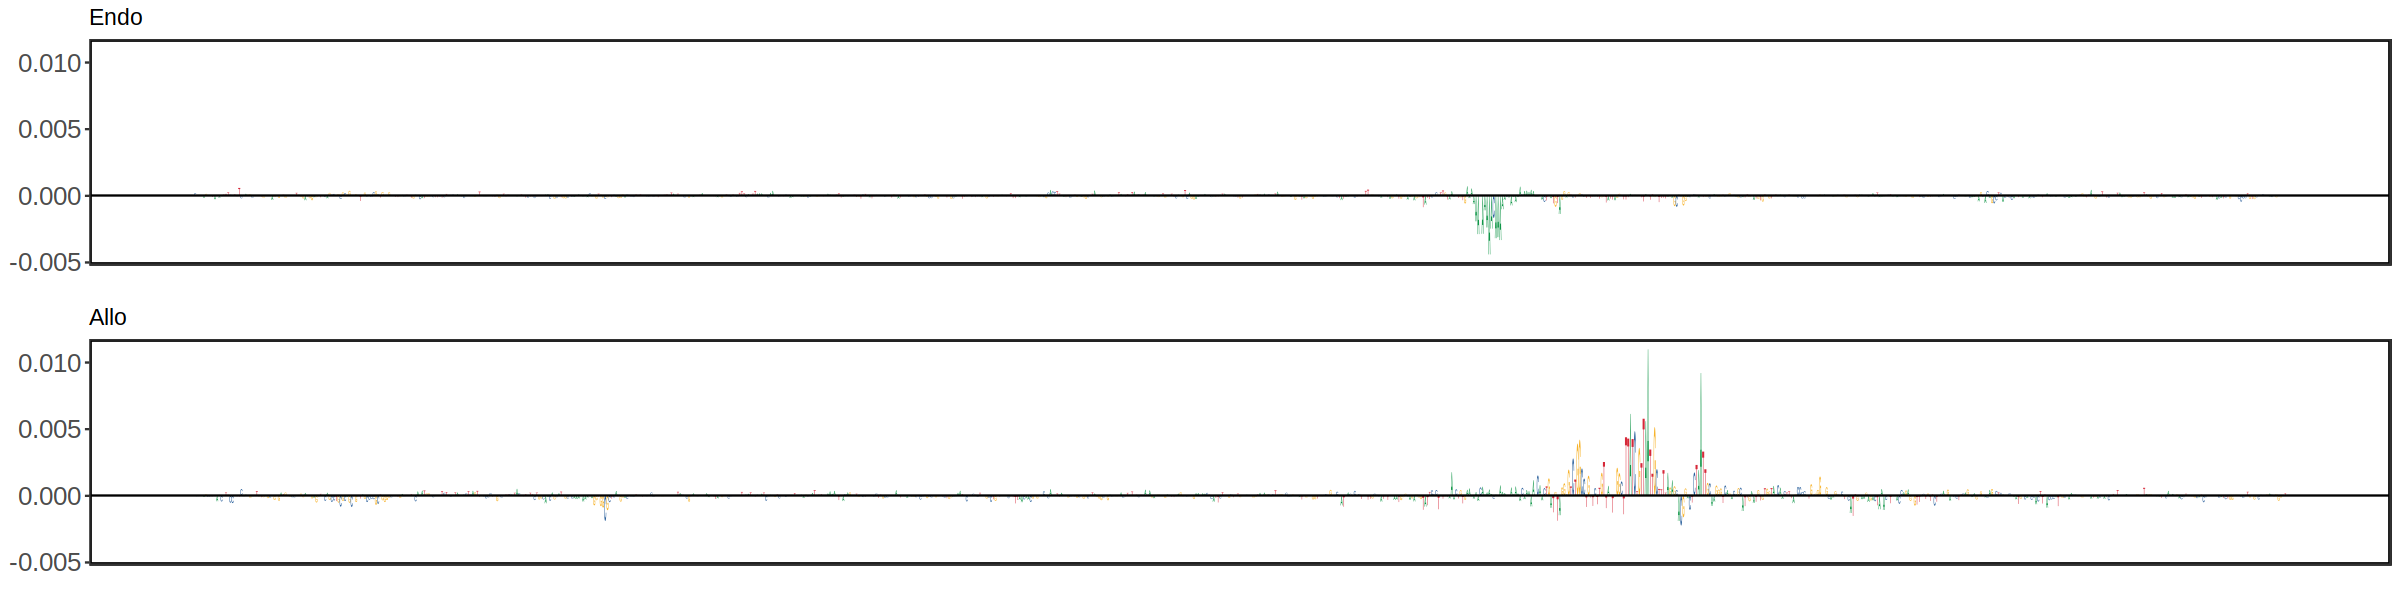

In [20]:
lapply(1:3, function(x){
    
    row = x
    endo = endo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_endo = as.matrix(t(data.table(A = endo[1:2114],
               C = endo[2115:4228],
               G =  endo[4229:6342],
               T =  endo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
                .[position > 550 & position < 1500] %>% 
                             .[, position := NULL]))

    allo = allo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_allo = as.matrix(t(data.table(A = allo[1:2114],
               C = allo[2115:4228],
               G =  allo[4229:6342],
               T =  allo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
                .[position > 550 & position < 1500] %>% 
                             .[, position := NULL]))
        
    min = min(c(genome_endo, genome_allo))
    max = max(c(genome_endo, genome_allo))
    options(repr.plot.width = 20, repr.plot.height = 5)
    
    #genome = genome[position > 800 & position < 1200]
    p1 = ggseqlogo(genome_endo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) +
        ylim(min, max) + 
        ggtitle('Endo') + 
            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())
    
    p2 = ggseqlogo(genome_allo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) + 
                ylim(min, max) + 
            ggtitle('Allo') + 

            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())

    p = ggarrange(p1, p2, ncol = 1)
    return(p)
})

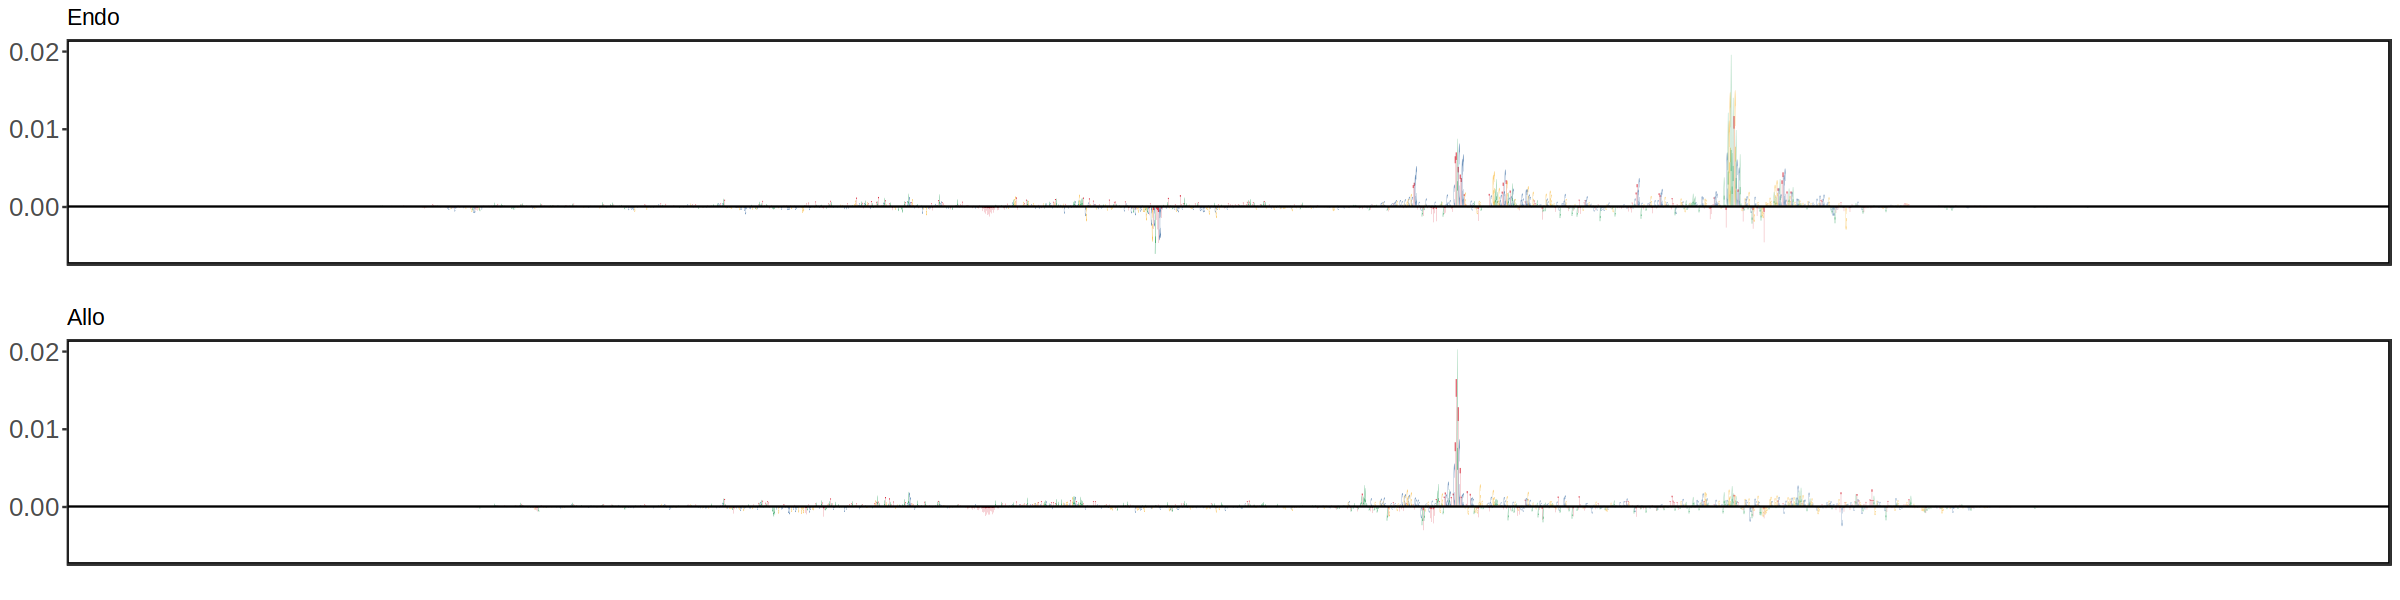

[[1]]

[[2]]

[[3]]


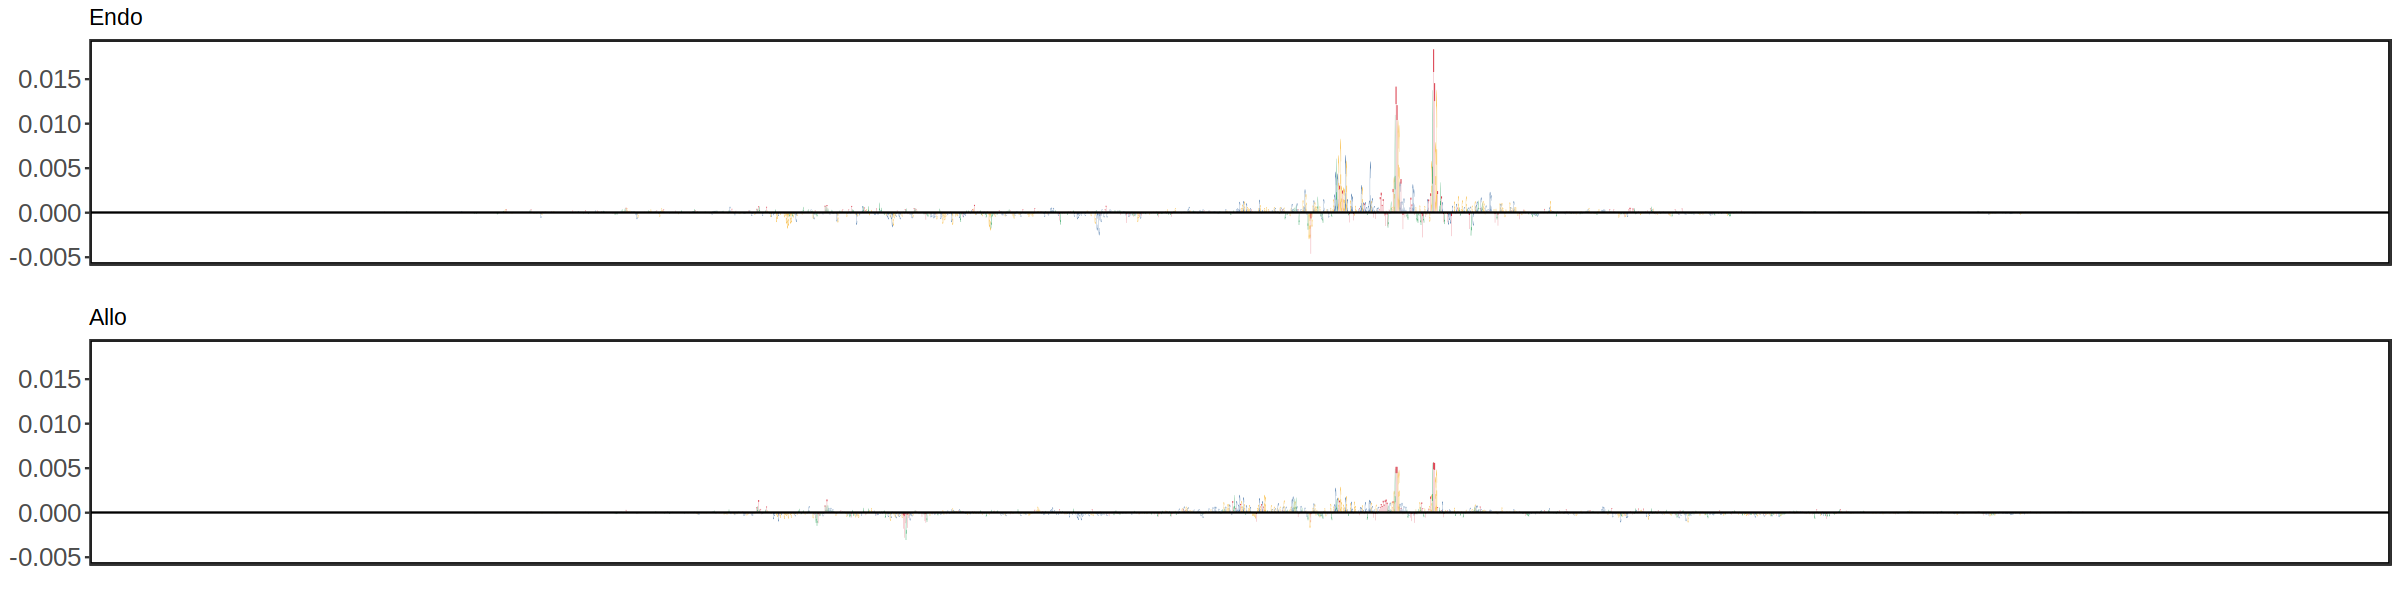

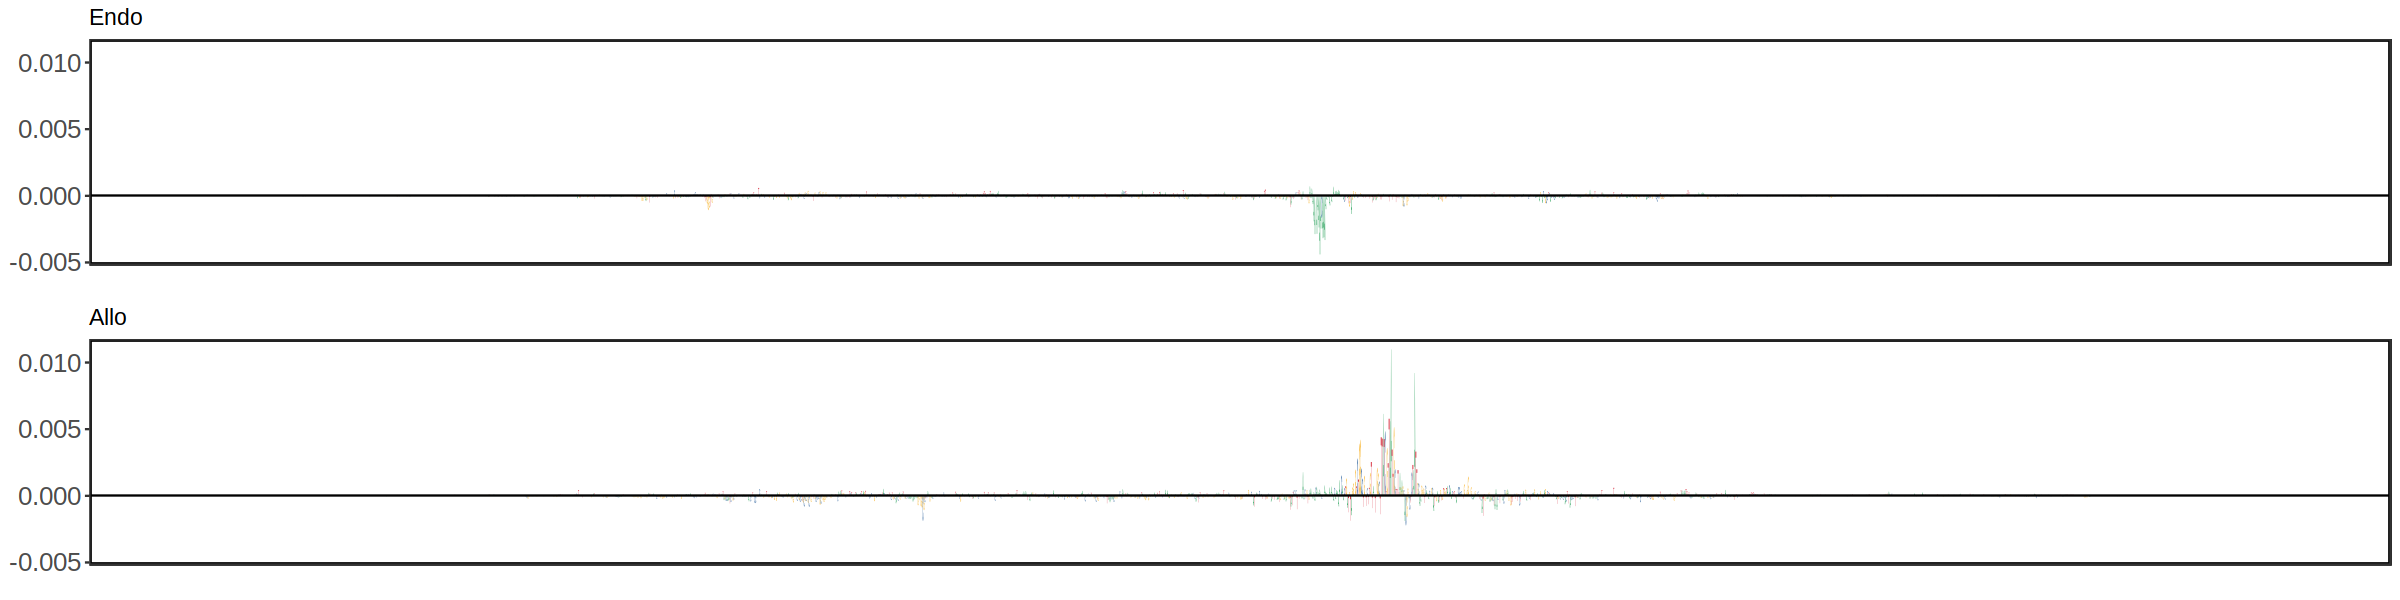

In [21]:
lapply(1:3, function(x){
    
    row = x
    endo = endo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_endo = as.matrix(t(data.table(A = endo[1:2114],
               C = endo[2115:4228],
               G =  endo[4229:6342],
               T =  endo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
             #   .[position > 550 & position < 1500] %>% 
                             .[, position := NULL]))

    allo = allo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_allo = as.matrix(t(data.table(A = allo[1:2114],
               C = allo[2115:4228],
               G =  allo[4229:6342],
               T =  allo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
            #    .[position > 550 & position < 1500] %>% 
                             .[, position := NULL]))
        
    min = min(c(genome_endo, genome_allo))
    max = max(c(genome_endo, genome_allo))
    options(repr.plot.width = 20, repr.plot.height = 5)
    
    #genome = genome[position > 800 & position < 1200]
    p1 = ggseqlogo(genome_endo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) +
        ylim(min, max) + 
        ggtitle('Endo') + 
            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())
    
    p2 = ggseqlogo(genome_allo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) + 
                ylim(min, max) + 
            ggtitle('Allo') + 

            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())

    p = ggarrange(p1, p2, ncol = 1)
    return(p)
})

## Counts prediction

In [22]:
celltype = 'Endothelium'
endo_h5 <- h5read('endo_test_prediction.counts_scores.h5', "/projected_shap/seq")
celltype = 'Allantois'
allo_h5 <- h5read('allo_test_prediction.counts_scores.h5', "/projected_shap/seq")

In [23]:
length(endo_h5)
length(allo_h5)

[1] 25368

[1] 25368

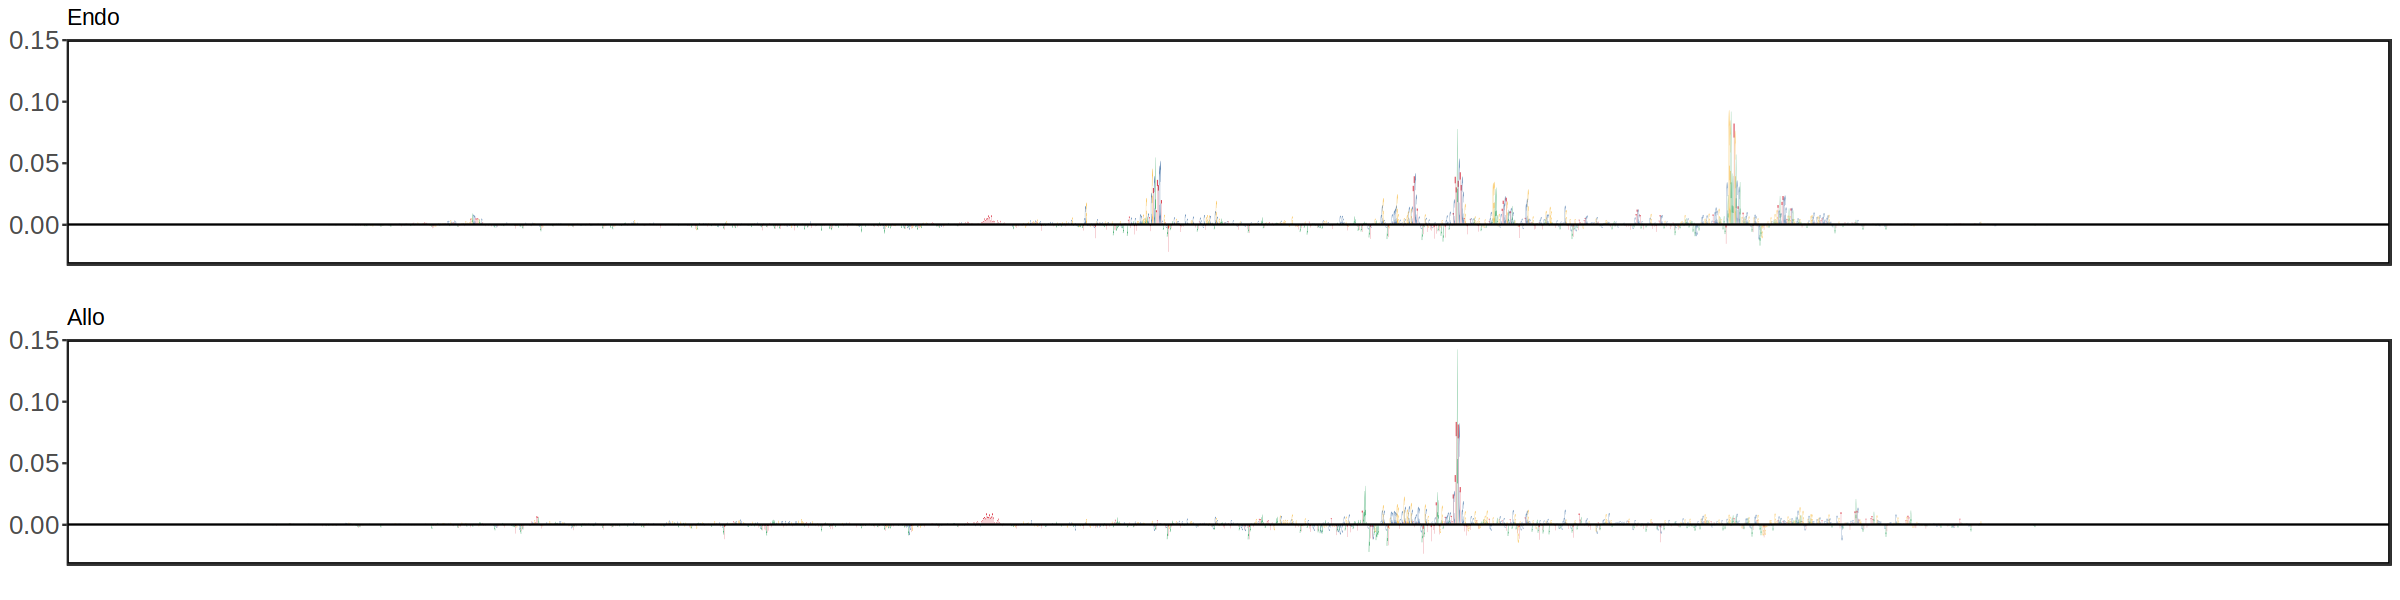

[[1]]

[[2]]

[[3]]


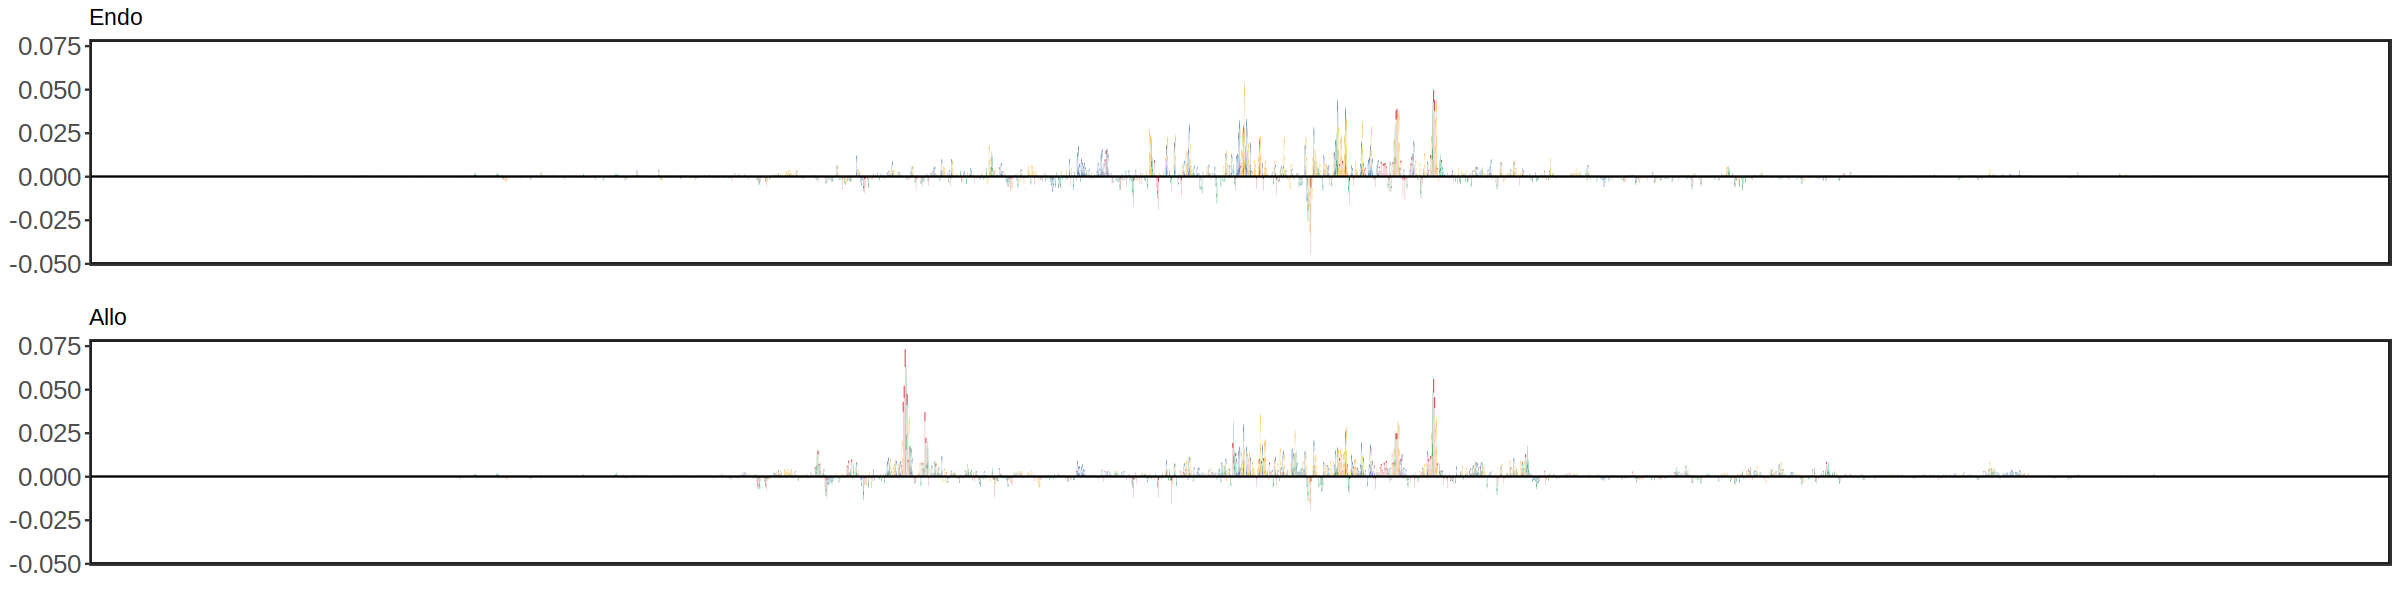

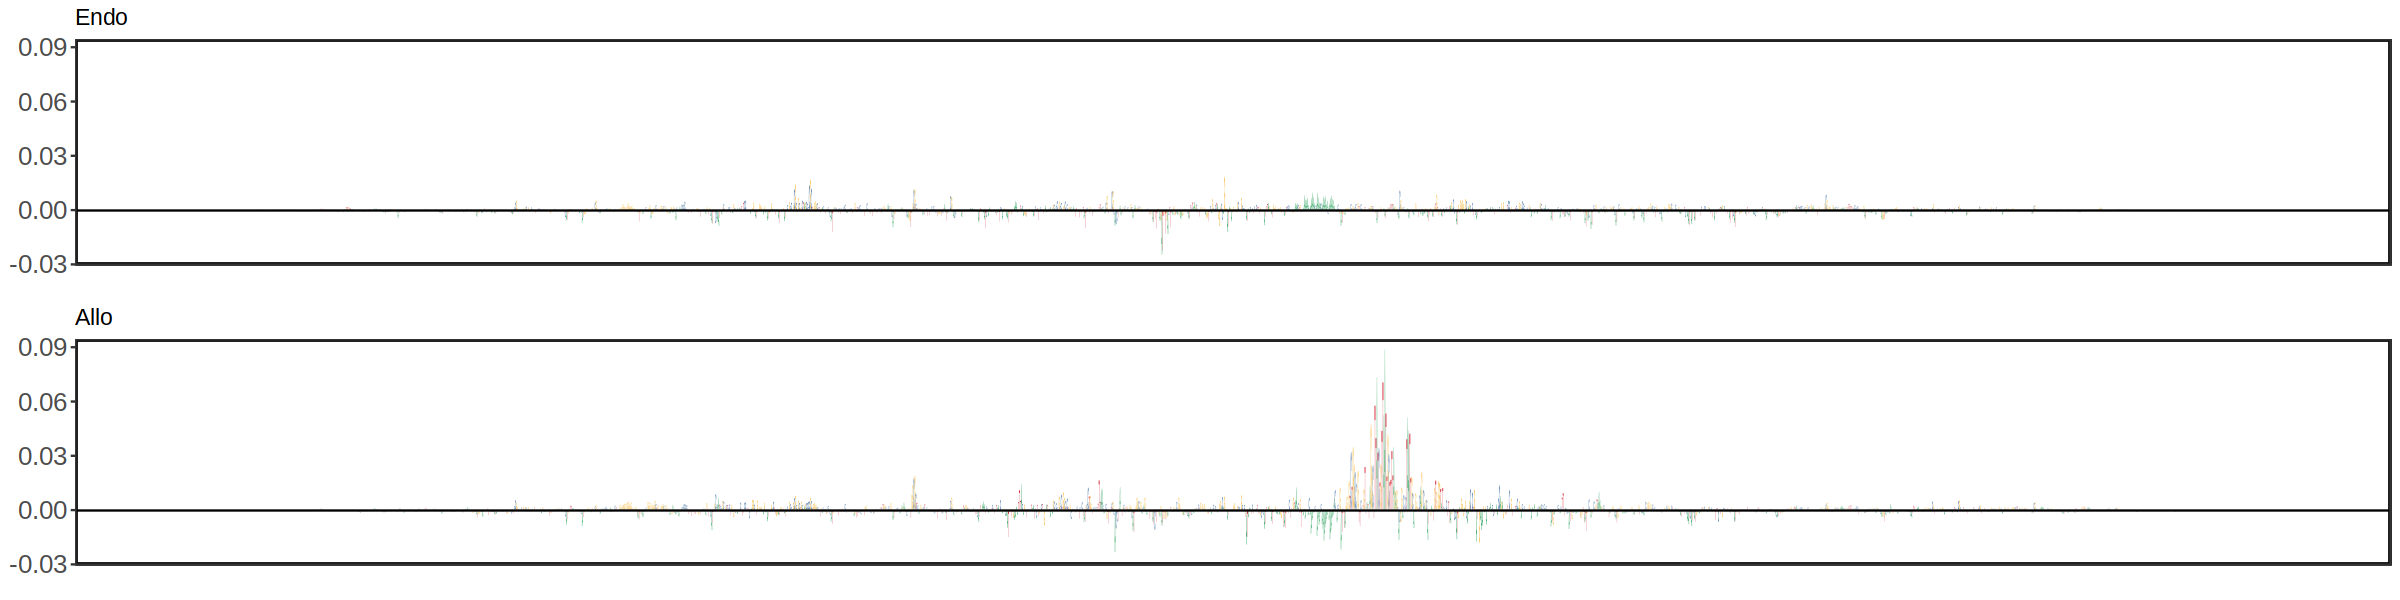

In [24]:
lapply(1:3, function(x){
    
    row = x
    endo = endo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_endo = as.matrix(t(data.table(A = endo[1:2114],
               C = endo[2115:4228],
               G =  endo[4229:6342],
               T =  endo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
                #.[position > 550 & position < 1500] %>% 
                             .[, position := NULL]))

    allo = allo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_allo = as.matrix(t(data.table(A = allo[1:2114],
               C = allo[2115:4228],
               G =  allo[4229:6342],
               T =  allo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
               # .[position > 550 & position < 1500] %>% 
                             .[, position := NULL]))
        
    min = min(c(genome_endo, genome_allo))
    max = max(c(genome_endo, genome_allo))
    options(repr.plot.width = 20, repr.plot.height = 5)
    
    #genome = genome[position > 800 & position < 1200]
    p1 = ggseqlogo(genome_endo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) +
        ylim(min, max) + 
        ggtitle('Endo') + 
            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())
    
    p2 = ggseqlogo(genome_allo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) + 
                ylim(min, max) + 
            ggtitle('Allo') + 

            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())

    p = ggarrange(p1, p2, ncol = 1)
    return(p)
})

[[1]]


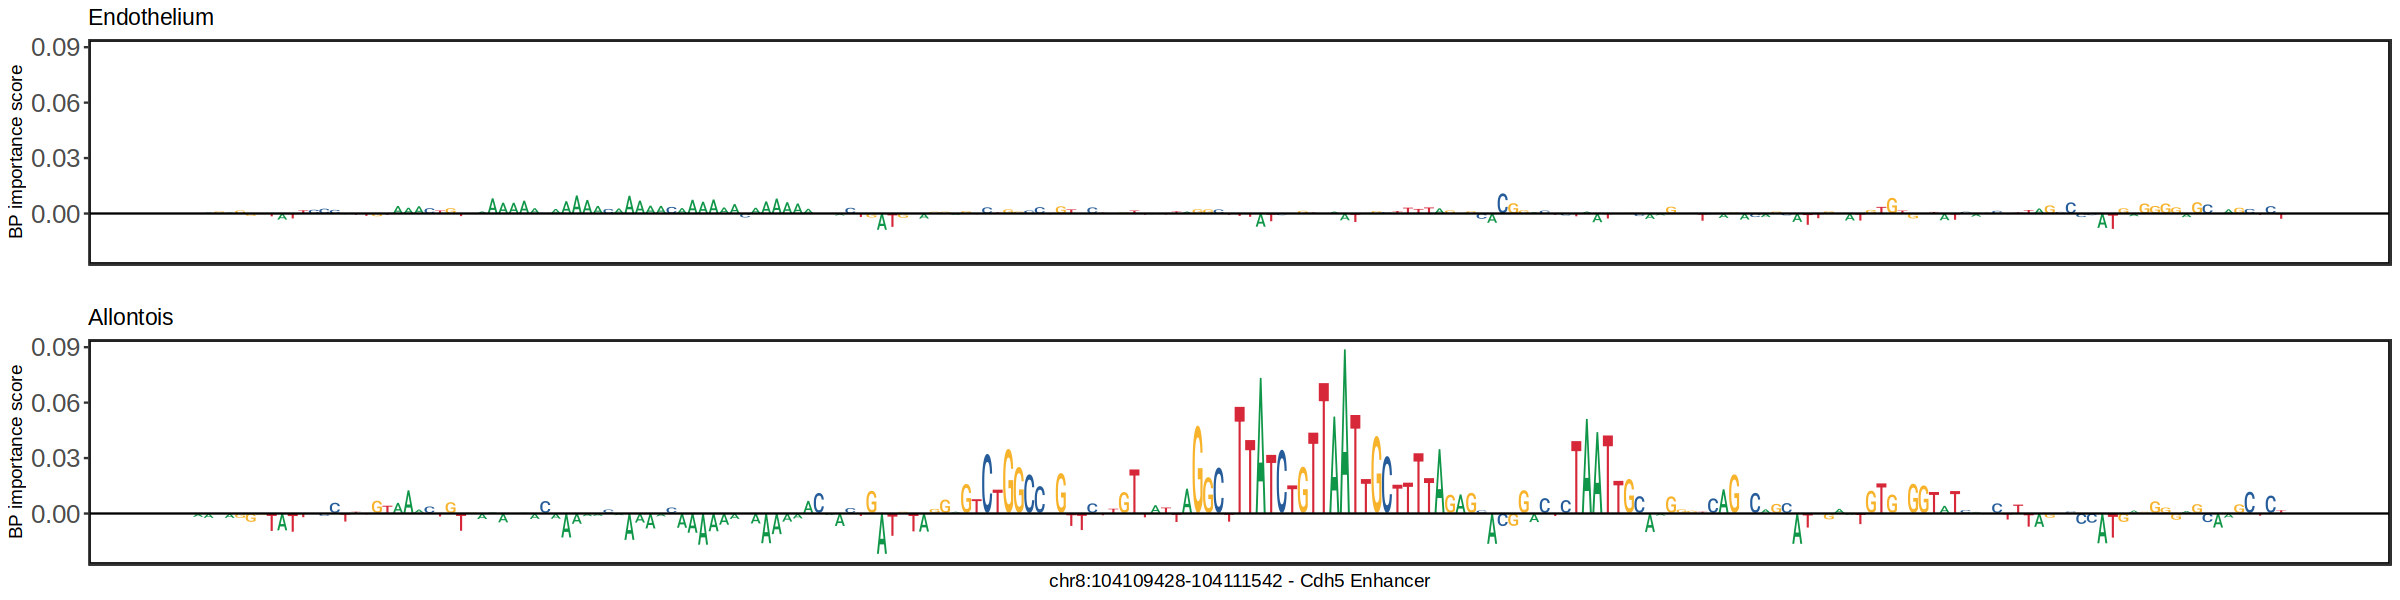

In [17]:
lapply(3, function(x){
    
    row = x
    endo = endo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_endo = as.matrix(t(data.table(A = endo[1:2114],
               C = endo[2115:4228],
               G =  endo[4229:6342],
               T =  endo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
                .[position > 1100 & position < 1300] %>% 
                             .[, position := NULL]))

    allo = allo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_allo = as.matrix(t(data.table(A = allo[1:2114],
               C = allo[2115:4228],
               G =  allo[4229:6342],
               T =  allo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
                .[position > 1100 & position < 1300] %>% 
                             .[, position := NULL]))
        
    min = min(c(genome_endo, genome_allo))
    max = max(c(genome_endo, genome_allo))
    options(repr.plot.width = 20, repr.plot.height = 5)
    
    #genome = genome[position > 800 & position < 1200]
    p1 = ggseqlogo(genome_endo, method='custom', seq_type='dna') + ylab('BP importance score') + 
        geom_hline(yintercept = 0) +
        ylim(min, max) + 
        ggtitle('Endothelium') + 
            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 # axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())
    
    p2 = ggseqlogo(genome_allo, method='custom', seq_type='dna') + ylab('BP importance score')  + xlab('chr8:104109428-104111542 - Cdh5 Enhancer') + 
        geom_hline(yintercept = 0) + 
                ylim(min, max) + 
            ggtitle('Allontois') + 

            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 #axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())

    p = ggarrange(p1, p2, ncol = 1)
    return(p)
})

In [27]:

celltype = 'Allantois'
allo_h5 <- h5read('allo_test_prediction.profile_scores.h5', "/projected_shap/seq")
# Calling it endo to not change code but testing allantois v1 on just allantois peaks model
endo_h5 <- h5read('allantois_v1_test_prediction.profile_scores.h5', "/projected_shap/seq")

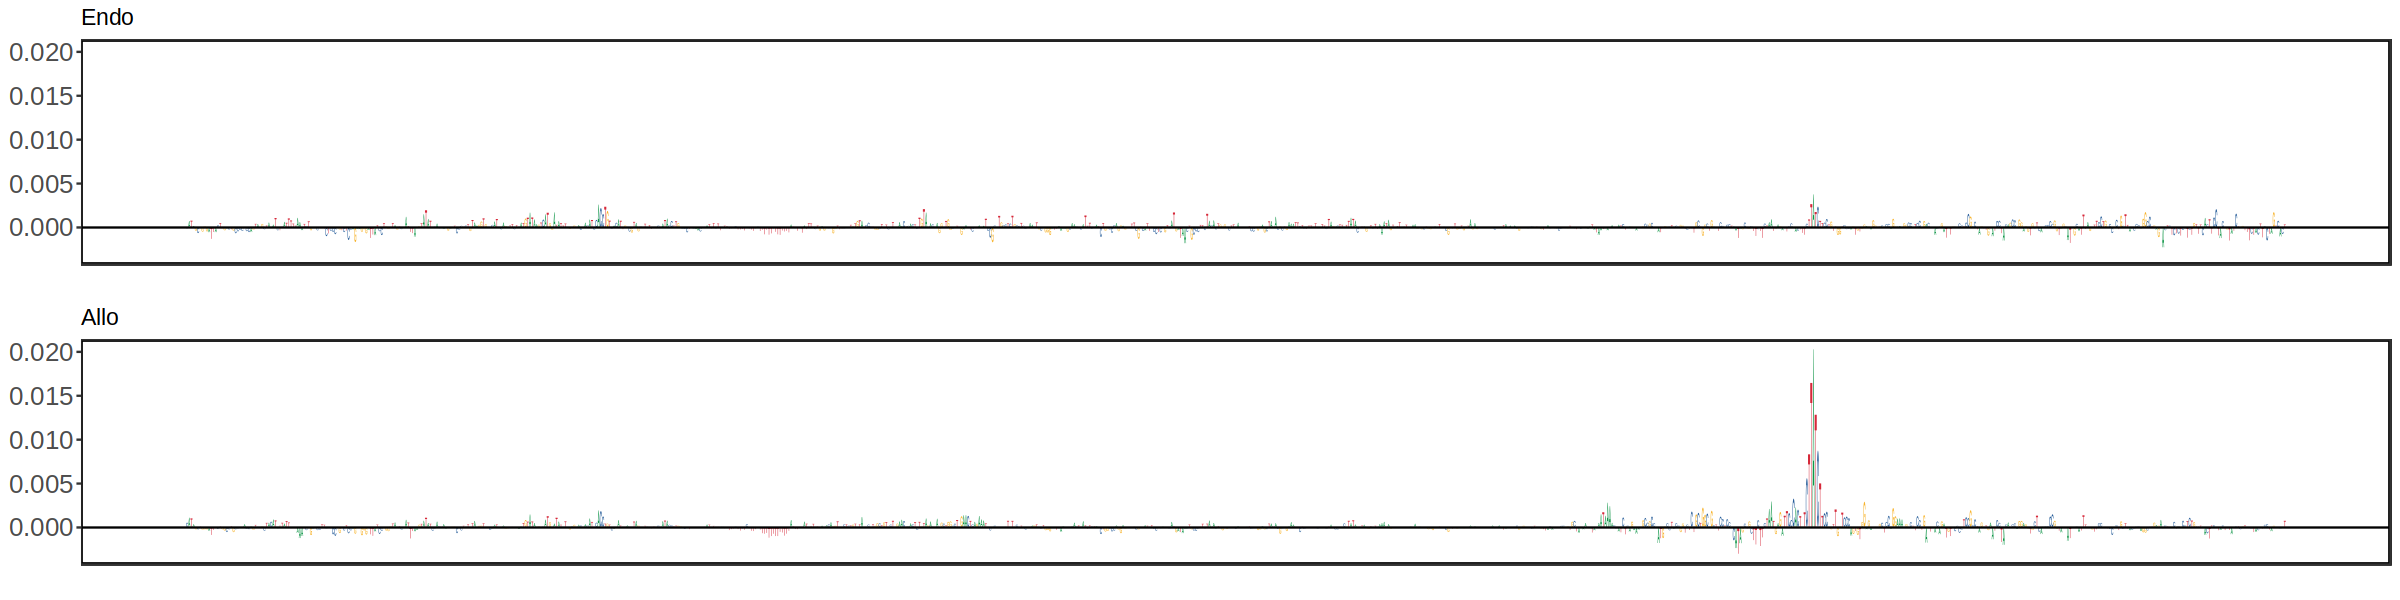

[[1]]

[[2]]

[[3]]


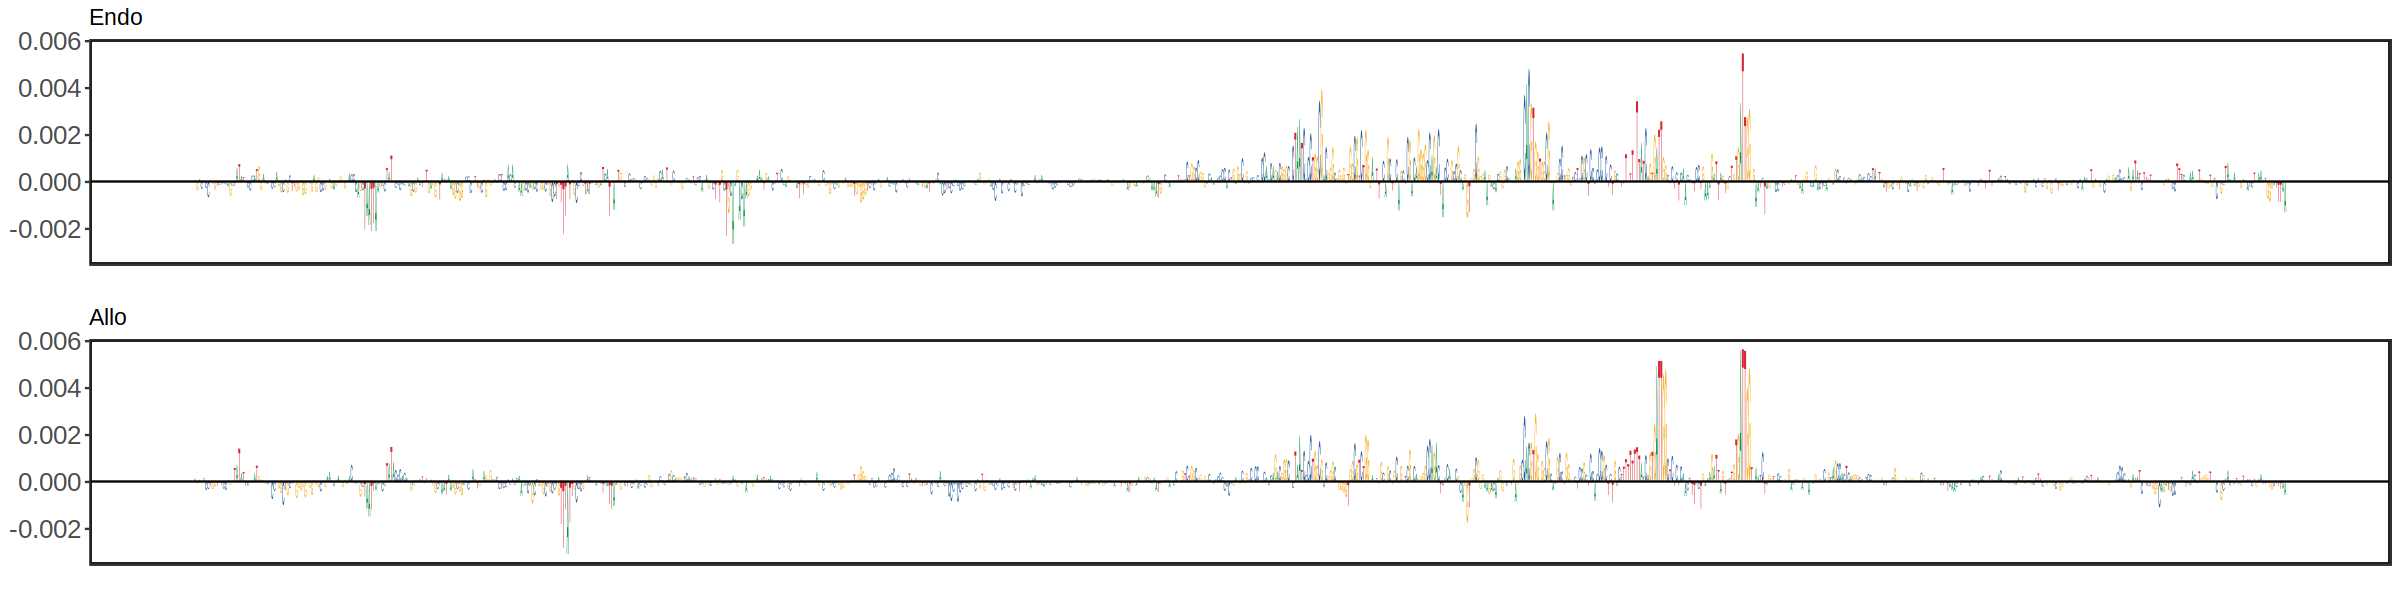

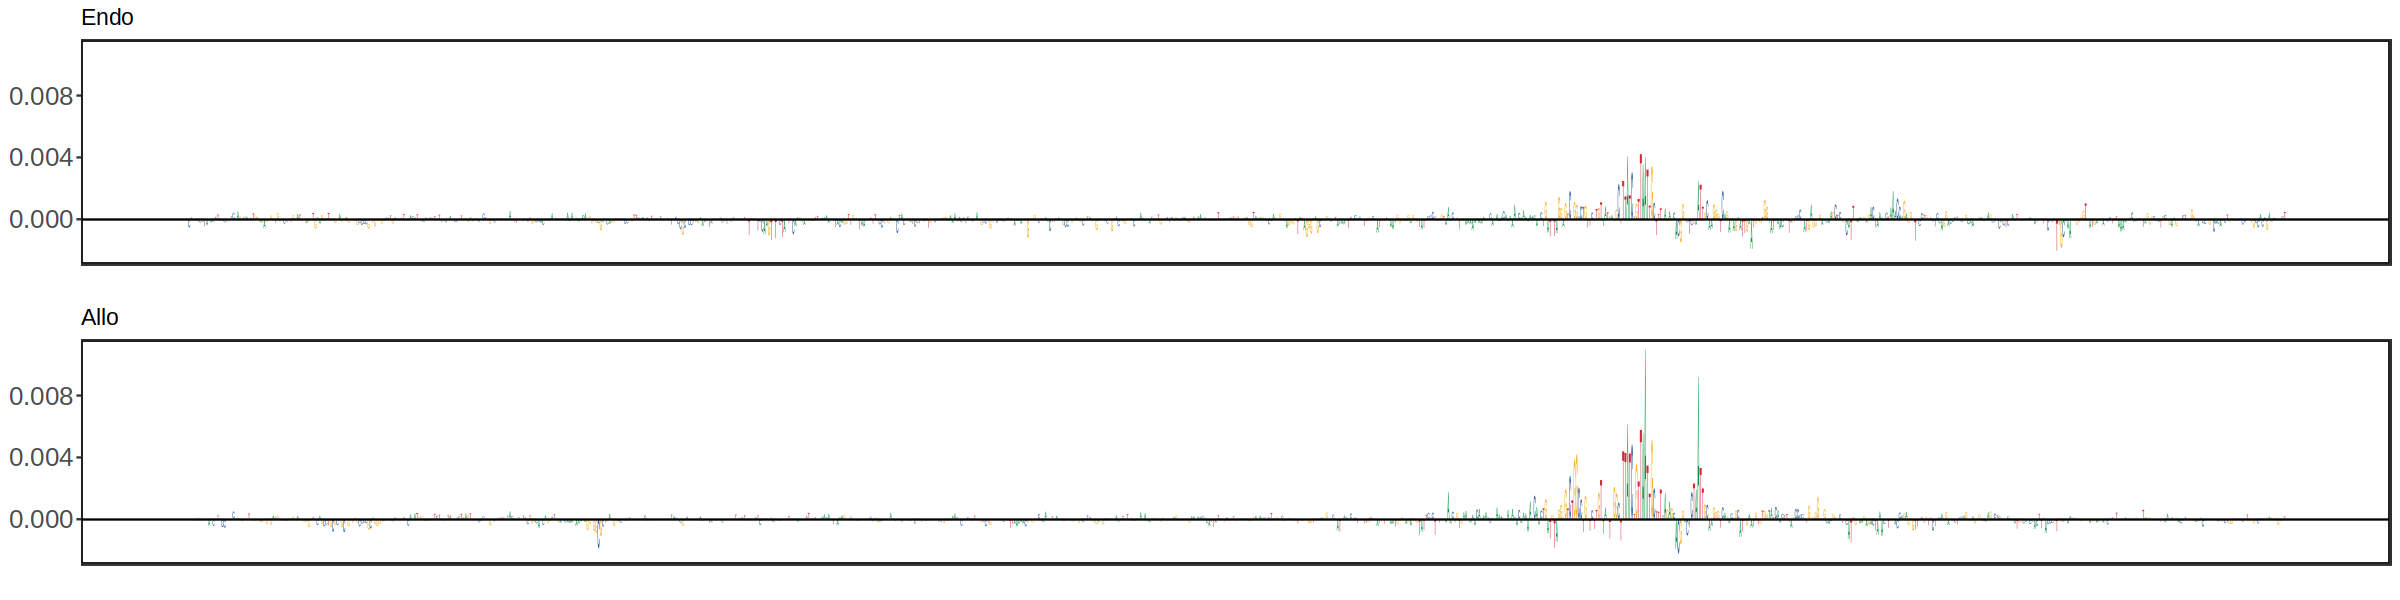

In [28]:
lapply(1:3, function(x){
    
    row = x
    endo = endo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_endo = as.matrix(t(data.table(A = endo[1:2114],
               C = endo[2115:4228],
               G =  endo[4229:6342],
               T =  endo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
                .[position > 550 & position < 1500] %>% 
                             .[, position := NULL]))

    allo = allo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_allo = as.matrix(t(data.table(A = allo[1:2114],
               C = allo[2115:4228],
               G =  allo[4229:6342],
               T =  allo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
                .[position > 550 & position < 1500] %>% 
                             .[, position := NULL]))
        
    min = min(c(genome_endo, genome_allo))
    max = max(c(genome_endo, genome_allo))
    options(repr.plot.width = 20, repr.plot.height = 5)
    
    #genome = genome[position > 800 & position < 1200]
    p1 = ggseqlogo(genome_endo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) +
        ylim(min, max) + 
        ggtitle('Endo') + 
            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())
    
    p2 = ggseqlogo(genome_allo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) + 
                ylim(min, max) + 
            ggtitle('Allo') + 

            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())

    p = ggarrange(p1, p2, ncol = 1)
    return(p)
})

In [ ]:
endo_h5 <- h5read('endo_test_prediction.counts_scores.h5', "/projected_shap/seq")
celltype = 'Allantois'
allo_h5 <- h5read('allo_test_prediction.counts_scores.h5', "/projected_shap/seq")

In [29]:

celltype = 'Allantois'
allo_h5 <- h5read('allo_test_prediction.counts_scores.h5', "/projected_shap/seq")
# Calling it endo to not change code but testing allantois v1 on just allantois peaks model
endo_h5 <- h5read('allantois_v1_test_prediction.counts_scores.h5', "/projected_shap/seq")

In [30]:
length(endo_h5)
length(allo_h5)

[1] 25368

[1] 25368

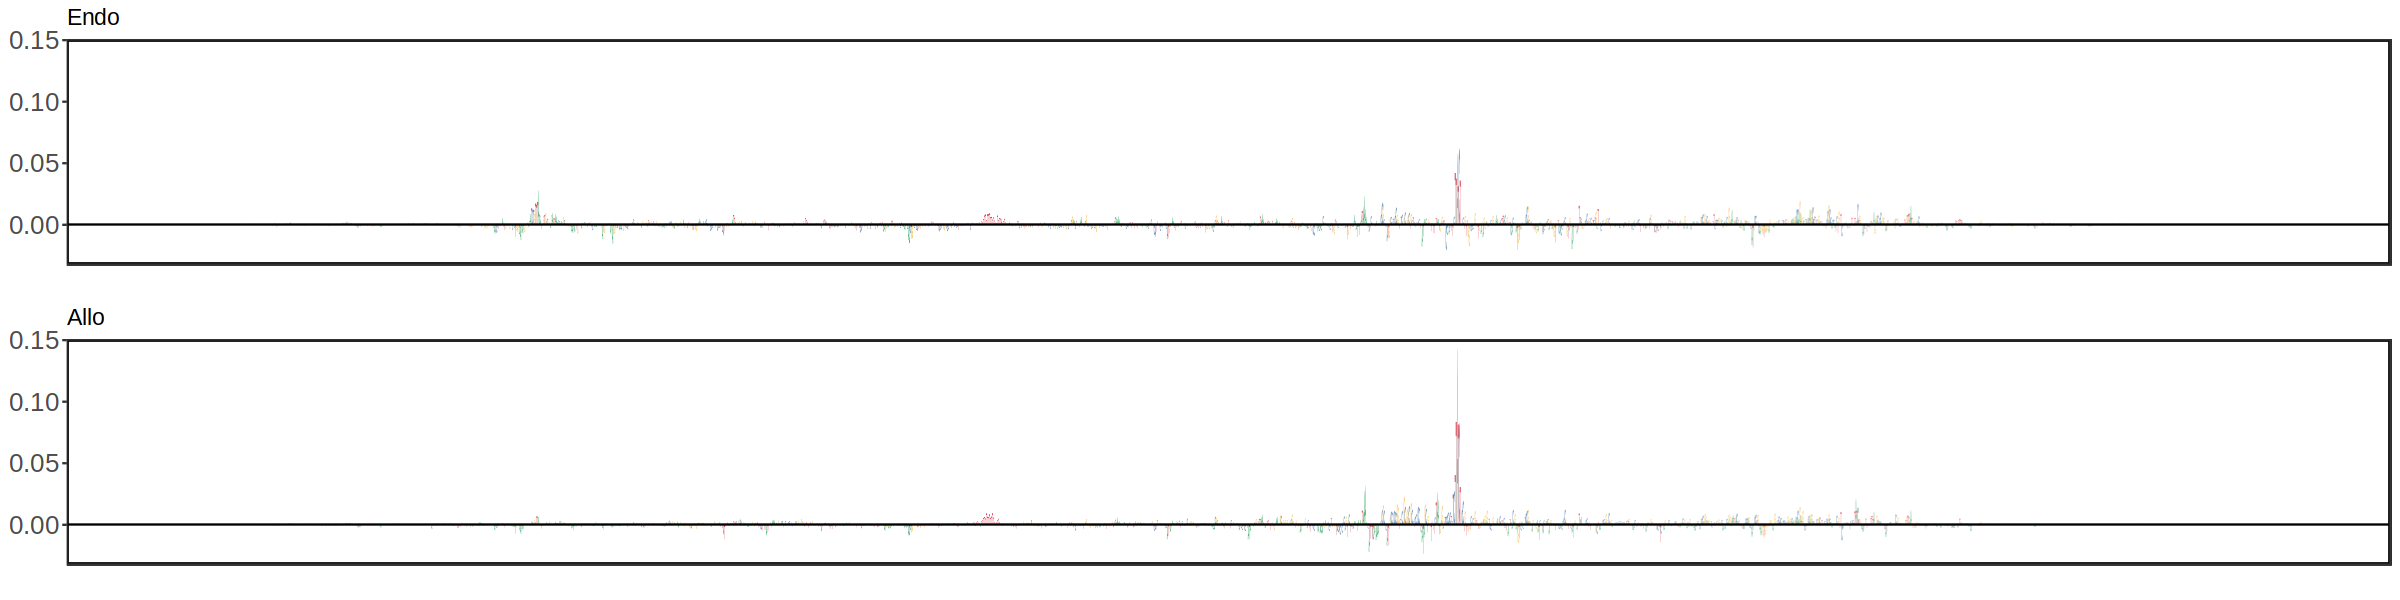

[[1]]

[[2]]

[[3]]


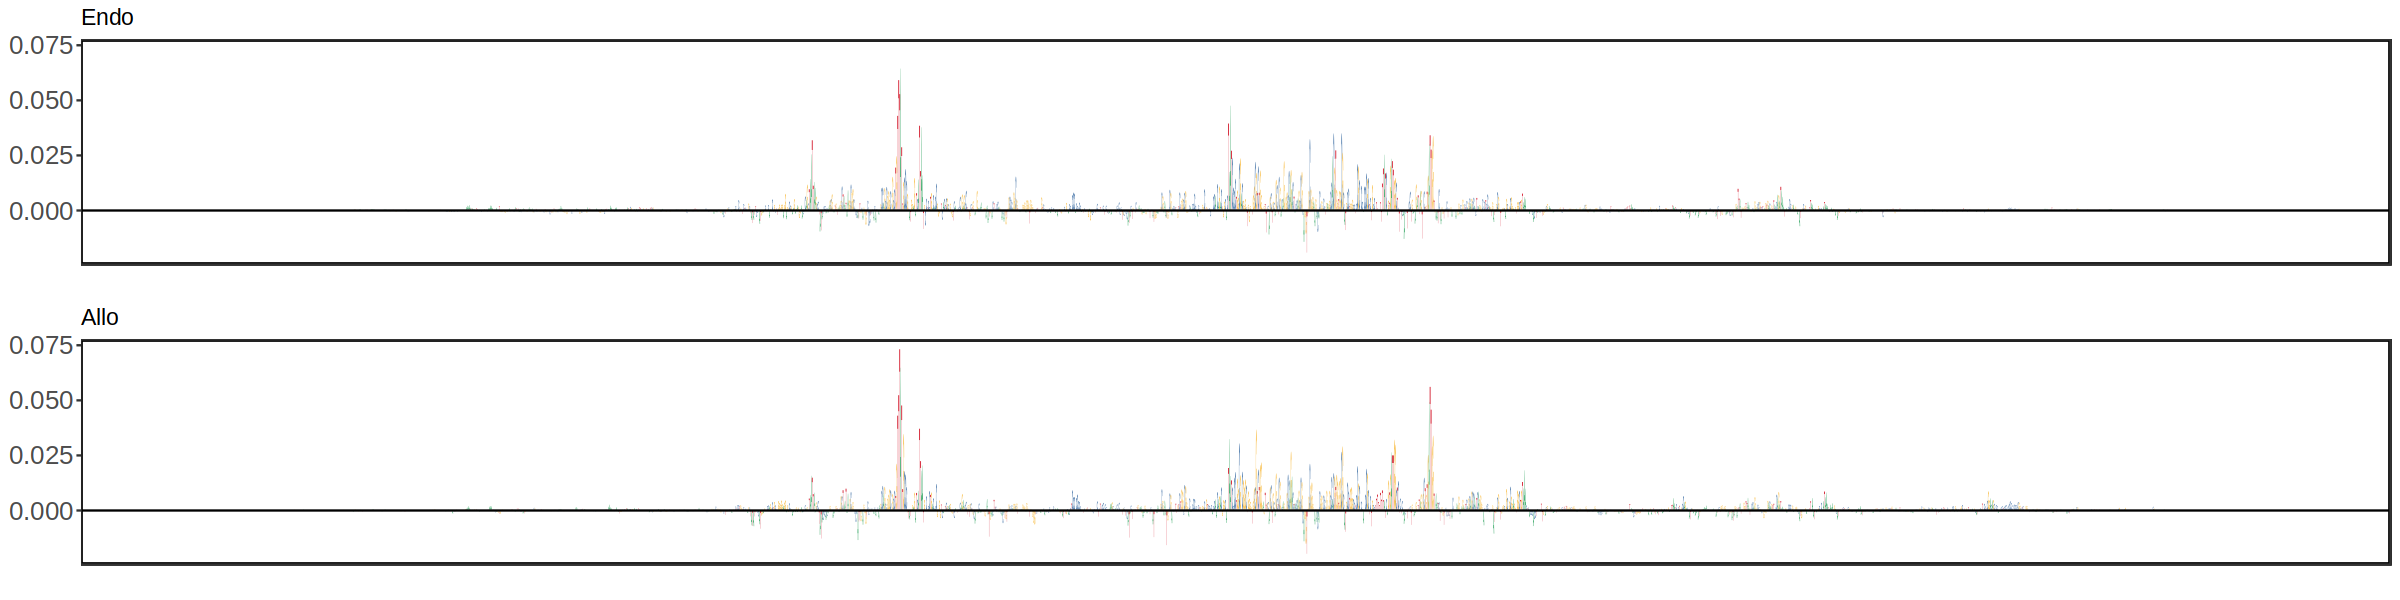

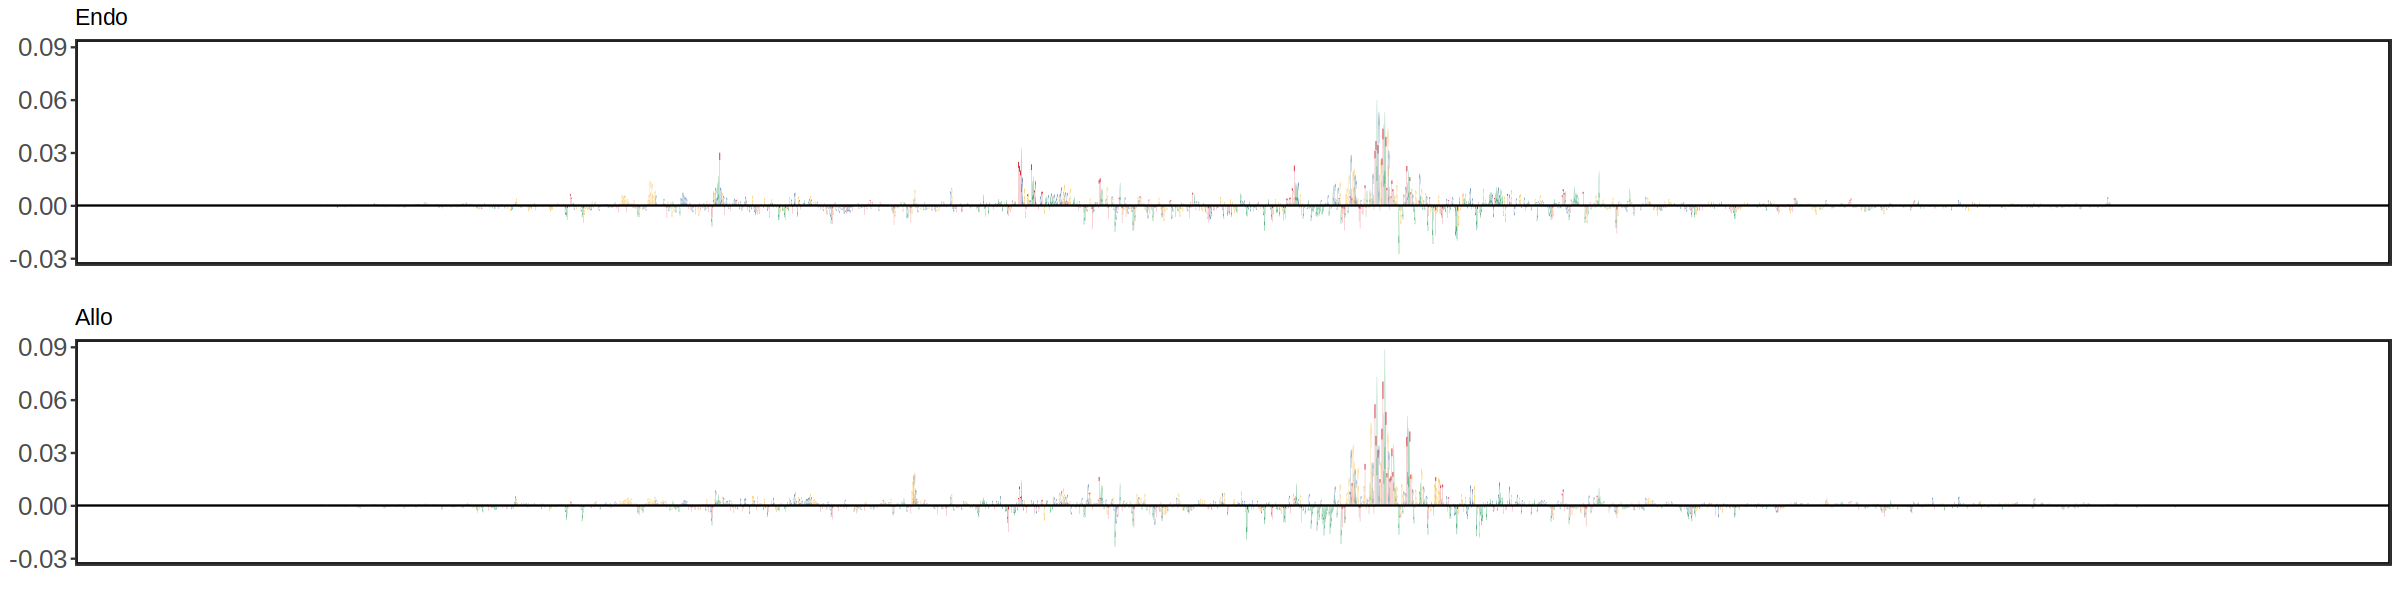

In [31]:
lapply(1:3, function(x){
    
    row = x
    endo = endo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_endo = as.matrix(t(data.table(A = endo[1:2114],
               C = endo[2115:4228],
               G =  endo[4229:6342],
               T =  endo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
                #.[position > 550 & position < 1500] %>% 
                             .[, position := NULL]))

    allo = allo_h5[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
    genome_allo = as.matrix(t(data.table(A = allo[1:2114],
               C = allo[2115:4228],
               G =  allo[4229:6342],
               T =  allo[6343:8456]
               ) %>% 
                .[, position := .I] %>% 
               # .[position > 550 & position < 1500] %>% 
                             .[, position := NULL]))
        
    min = min(c(genome_endo, genome_allo))
    max = max(c(genome_endo, genome_allo))
    options(repr.plot.width = 20, repr.plot.height = 5)
    
    #genome = genome[position > 800 & position < 1200]
    p1 = ggseqlogo(genome_endo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) +
        ylim(min, max) + 
        ggtitle('Endo') + 
            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())
    
    p2 = ggseqlogo(genome_allo, method='custom', seq_type='dna') + ylab('my custom height') + 
        geom_hline(yintercept = 0) + 
                ylim(min, max) + 
            ggtitle('Allo') + 

            theme_bw() + 
            theme(panel.grid = element_blank(), 
                  panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                  axis.text.y = element_text(size = 15),
                 axis.title.y = element_blank(),
                 axis.text.x = element_blank(),
                 axis.ticks.x = element_blank())

    p = ggarrange(p1, p2, ncol = 1)
    return(p)
})